In [1]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 43.2 MB/s eta 0:00:00


In [2]:
import joblib
import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import seaborn as sns
import tensorflow as tf
import yfinance as yf
from pmdarima import auto_arima
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Sequential
from tqdm import tqdm

2025-08-07 21:35:34.184291: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754602534.426526      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754602534.499618      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
stocks = ['AAPL', 'TSLA', 'MSFT']
end_date = '2025-04-01'

In [4]:
data = {}
for stock in stocks:
    df = yf.download(tickers=stock, period='max', interval='1d', auto_adjust=False)
    data[stock] = df

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [5]:
for stock in stocks:
    df = data[stock].copy()
    df.columns = [col[0] for col in df.columns]
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df = df.loc[:end_date]
    # df = df.reset_index()
    # start_dates[stock] = df['Date'][0].strftime('%Y-%m-%d')
    df.to_csv(f'{stock}.csv', index=False)
    print(f'{stock}.csv saved')
    data[stock] = df

AAPL.csv saved
TSLA.csv saved
MSFT.csv saved


In [6]:
for stock in stocks:
    df = data[stock].copy()
    print(stock)
    display(df.head())
    print(df.info())
    display(df.describe())

AAPL


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
1980-12-12,0.098597,0.128348,0.128906,0.128348,0.128348,469033600
1980-12-15,0.093453,0.121652,0.122210,0.121652,0.122210,175884800
1980-12-16,0.086594,0.112723,0.113281,0.112723,0.113281,105728000
1980-12-17,0.088737,0.115513,0.116071,0.115513,0.115513,86441600
1980-12-18,0.091310,0.118862,0.119420,0.118862,0.118862,73449600


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11166 entries, 1980-12-12 to 2025-04-01
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  11166 non-null  float64
 1   Close      11166 non-null  float64
 2   High       11166 non-null  float64
 3   Low        11166 non-null  float64
 4   Open       11166 non-null  float64
 5   Volume     11166 non-null  int64  
dtypes: float64(5), int64(1)
memory usage: 610.6 KB
None


,Adj Close,Close,High,Low,Open,Volume
count,11166.000000,11166.000000,11166.000000,11166.000000,11166.000000,1.116600e+04
mean,24.560692,25.450088,25.703902,25.170562,25.430552,3.140486e+08
std,51.751557,52.285014,52.790287,51.716920,52.232777,3.345300e+08
min,0.037724,0.049107,0.049665,0.049107,0.049665,0.000000e+00
25%,0.243985,0.301339,0.308036,0.294643,0.301339,1.099329e+08
50%,0.452794,0.553125,0.562500,0.542634,0.551205,2.024512e+08
75%,18.764460,22.084911,22.303393,21.834286,22.093840,3.945074e+08
max,258.396667,259.019989,260.100006,257.630005,258.190002,7.421641e+09


TSLA


...

,Adj Close,Close,High,Low,Open,Volume
count,3713.000000,3713.000000,3713.000000,3713.000000,3713.000000,3.713000e+03
mean,85.642782,85.642782,87.576508,83.641004,85.687683,9.669388e+07
std,111.707808,111.707808,114.344809,109.031796,111.836794,7.721205e+07
min,1.053333,1.053333,1.108667,0.998667,1.076000,1.777500e+06
25%,12.301333,12.301333,12.568000,12.066667,12.282667,4.958700e+07
50%,18.492666,18.492666,18.760000,18.220667,18.506666,8.243970e+07
75%,184.860001,184.860001,188.500000,180.630005,184.990005,1.222880e+08
max,479.859985,479.859985,488.540009,457.510010,475.899994,9.140820e+08


MSFT


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
1986-03-13,0.059598,0.097222,0.101563,0.088542,0.088542,1031788800
1986-03-14,0.061726,0.100694,0.102431,0.097222,0.097222,308160000
1986-03-17,0.062791,0.102431,0.103299,0.100694,0.100694,133171200
1986-03-18,0.061194,0.099826,0.103299,0.098958,0.102431,67766400
1986-03-19,0.060130,0.098090,0.100694,0.097222,0.099826,47894400


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9840 entries, 1986-03-13 to 2025-04-01
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  9840 non-null   float64
 1   Close      9840 non-null   float64
 2   High       9840 non-null   float64
 3   Low        9840 non-null   float64
 4   Open       9840 non-null   float64
 5   Volume     9840 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 538.1 KB
None


,Adj Close,Close,High,Low,Open,Volume
count,9840.000000,9840.000000,9840.000000,9840.000000,9840.000000,9.840000e+03
mean,58.607483,64.542660,65.180101,63.855171,64.528489,5.617340e+07
std,100.474760,100.759478,101.654930,99.765018,100.742524,3.810446e+07
min,0.055341,0.090278,0.092014,0.088542,0.088542,2.304000e+06
25%,3.648100,5.951172,6.044922,5.867188,5.953125,3.120422e+07
50%,19.244098,27.540001,27.835000,27.232187,27.500000,4.926150e+07
75%,40.467114,48.219063,48.804999,47.610001,48.117812,7.018878e+07
max,464.002472,467.559998,468.350006,464.459991,467.000000,1.031789e+09


In [7]:
df_adjclose = pd.DataFrame()
for stock in stocks:
    df_adjclose[stock] = data[stock]['Adj Close']

df_adjclose

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,AAPL,TSLA,MSFT
Date,,,
1980-12-12,0.098597,NaN,NaN
1980-12-15,0.093453,NaN,NaN
1980-12-16,0.086594,NaN,NaN
1980-12-17,0.088737,NaN,NaN
1980-12-18,0.091310,NaN,NaN
...,...,...,...
2025-03-26,221.239868,272.059998,389.255402
2025-03-27,223.556839,273.130005,389.864258
2025-03-28,217.614624,263.549988,378.105835


In [8]:
#Plot Adjusted closing price
def plot_adj_close(df_adjclose):
    fig = go.Figure()
    for column in df_adjclose.columns:
        fig.add_trace(go.Scatter(x=df_adjclose.index, y=df_adjclose[column], mode='lines', name=column))
    
    fig.update_layout(
        title='Adjusted closing prices of stocks',
        xaxis_title='Date',
        yaxis_title='Price (USD)',
        legend_title='Stocks',
        template='plotly_dark',
        hovermode='x unified'
    )
    fig.show()
    
plot_adj_close(df_adjclose)

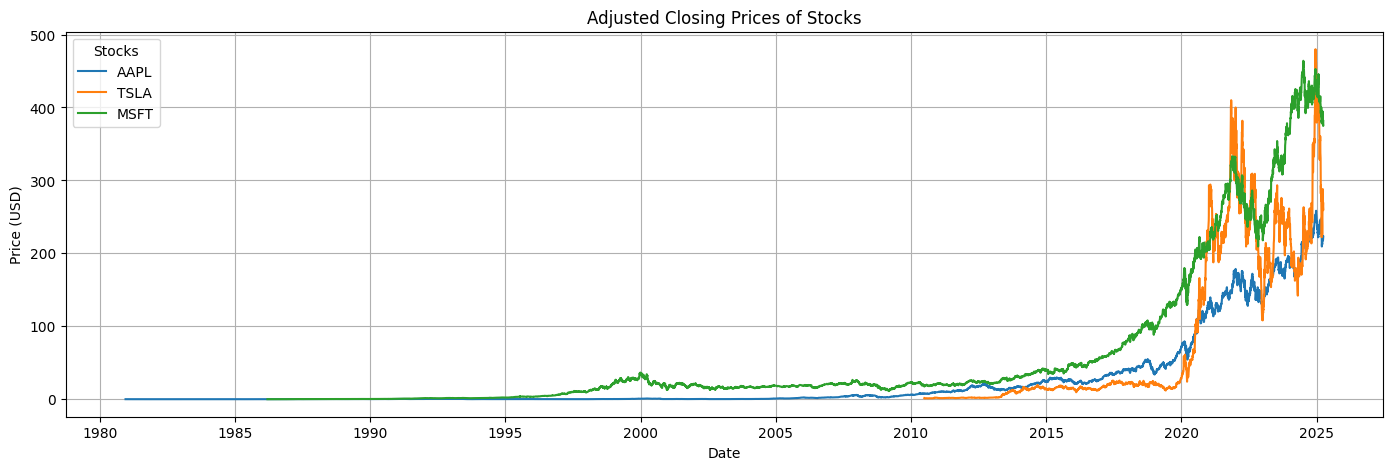

In [9]:
def plot_adj_close_matplotlib(df_adjclose):
    plt.figure(figsize=(17, 5))
    for column in df_adjclose.columns:
        plt.plot(df_adjclose.index, df_adjclose[column], label=column)

    plt.title('Adjusted Closing Prices of Stocks')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend(title='Stocks')
    plt.grid(True)
    plt.show()
    
plot_adj_close_matplotlib(df_adjclose)

In the plot, we can see that before Tesla's stock data appears (around 2010), Apple and Microsoft remained relatively steady. After 2010, all three stocks show an upward trend with increasing volatility. Since Tesla's earlier data is missing (NaN), I’ll drop the data before Tesla using dropna().

In [10]:
df_adjclose = df_adjclose.dropna()

#Adding all the business day date range
full_index = pd.date_range(start=df_adjclose.index.min(), end=df_adjclose.index.max(), freq='B')
print('Original Trading dates:', len(df_adjclose))

#reindex and forward fill missing the prices
df_adjclose = df_adjclose.reindex(full_index).ffill()
print('Business days filled', len(df_adjclose))

Original Trading dates: 3713
Business days filled 3851


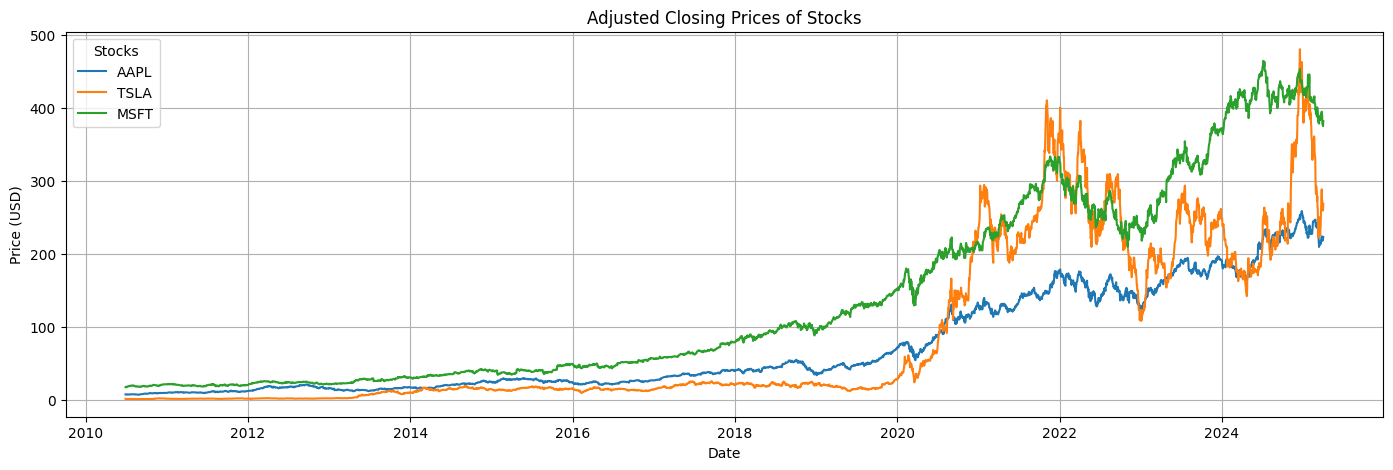

In [11]:
# Ploting the Adjusted closing price again after removing all the NaN values and getting all the dates of the business calender
plot_adj_close(df_adjclose)
plot_adj_close_matplotlib(df_adjclose)

From 2020 onwards, all three stocks AAPL, TSLA, and MSFT show a sharp rise followed by increased volatility. Tesla in particular experienced rapid price swings, while Microsoft and Apple had a steadier upward trend. This period marks significant market movement, likely influenced by post-pandemic recovery and tech sector growth.


Summary Statistics for AAPL


,Adj Close,Close,High,Low,Open,Volume
count,11166.000000,11166.000000,11166.000000,11166.000000,11166.000000,1.116600e+04
mean,24.560692,25.450088,25.703902,25.170562,25.430552,3.140486e+08
std,51.751557,52.285014,52.790287,51.716920,52.232777,3.345300e+08
min,0.037724,0.049107,0.049665,0.049107,0.049665,0.000000e+00
25%,0.243985,0.301339,0.308036,0.294643,0.301339,1.099329e+08
50%,0.452794,0.553125,0.562500,0.542634,0.551205,2.024512e+08
75%,18.764460,22.084911,22.303393,21.834286,22.093840,3.945074e+08
max,258.396667,259.019989,260.100006,257.630005,258.190002,7.421641e+09


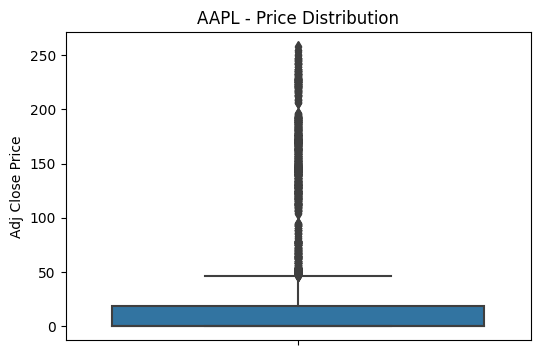


Summary Statistics for TSLA


,Adj Close,Close,High,Low,Open,Volume
count,3713.000000,3713.000000,3713.000000,3713.000000,3713.000000,3.713000e+03
mean,85.642782,85.642782,87.576508,83.641004,85.687683,9.669388e+07
std,111.707808,111.707808,114.344809,109.031796,111.836794,7.721205e+07
min,1.053333,1.053333,1.108667,0.998667,1.076000,1.777500e+06
25%,12.301333,12.301333,12.568000,12.066667,12.282667,4.958700e+07
50%,18.492666,18.492666,18.760000,18.220667,18.506666,8.243970e+07
75%,184.860001,184.860001,188.500000,180.630005,184.990005,1.222880e+08
max,479.859985,479.859985,488.540009,457.510010,475.899994,9.140820e+08


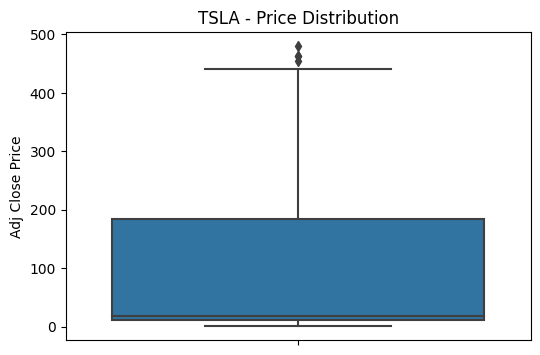


Summary Statistics for MSFT


,Adj Close,Close,High,Low,Open,Volume
count,9840.000000,9840.000000,9840.000000,9840.000000,9840.000000,9.840000e+03
mean,58.607483,64.542660,65.180101,63.855171,64.528489,5.617340e+07
std,100.474760,100.759478,101.654930,99.765018,100.742524,3.810446e+07
min,0.055341,0.090278,0.092014,0.088542,0.088542,2.304000e+06
25%,3.648100,5.951172,6.044922,5.867188,5.953125,3.120422e+07
50%,19.244098,27.540001,27.835000,27.232187,27.500000,4.926150e+07
75%,40.467114,48.219063,48.804999,47.610001,48.117812,7.018878e+07
max,464.002472,467.559998,468.350006,464.459991,467.000000,1.031789e+09


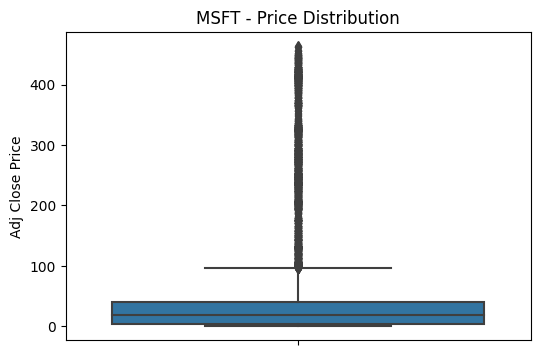

In [12]:
# Summary Statistics and boxplot of Adj Close
for stock in stocks:
    df = data[stock].copy()
    print(f"\nSummary Statistics for {stock}")
    display(df.describe())

    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df['Adj Close'])
    plt.title(f'{stock} - Price Distribution')
    plt.ylabel('Adj Close Price')
    plt.show()

In [13]:
# Plotting open and close for the year 2022 to see the fluctuations
def plot_open_close(stock, df): 
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=df.index, y=df['Open'], mode='lines', name='Open'))
    fig.add_trace(go.Scatter(x=df.index, y=df['Close'], mode='lines', name='Close'))
    
    fig.update_layout(
        title=f'Open and Close Stock Prices Over Time for {stock}',
        xaxis_title='Date',
        yaxis_title='Price (USD)',
        legend_title='Price Type',
        template='plotly_dark',
        hovermode='x unified'
    )
    fig.show()

for stock in stocks:
    df_plot = data[stock].loc['2022'].copy()
    plot_open_close(stock, df_plot)

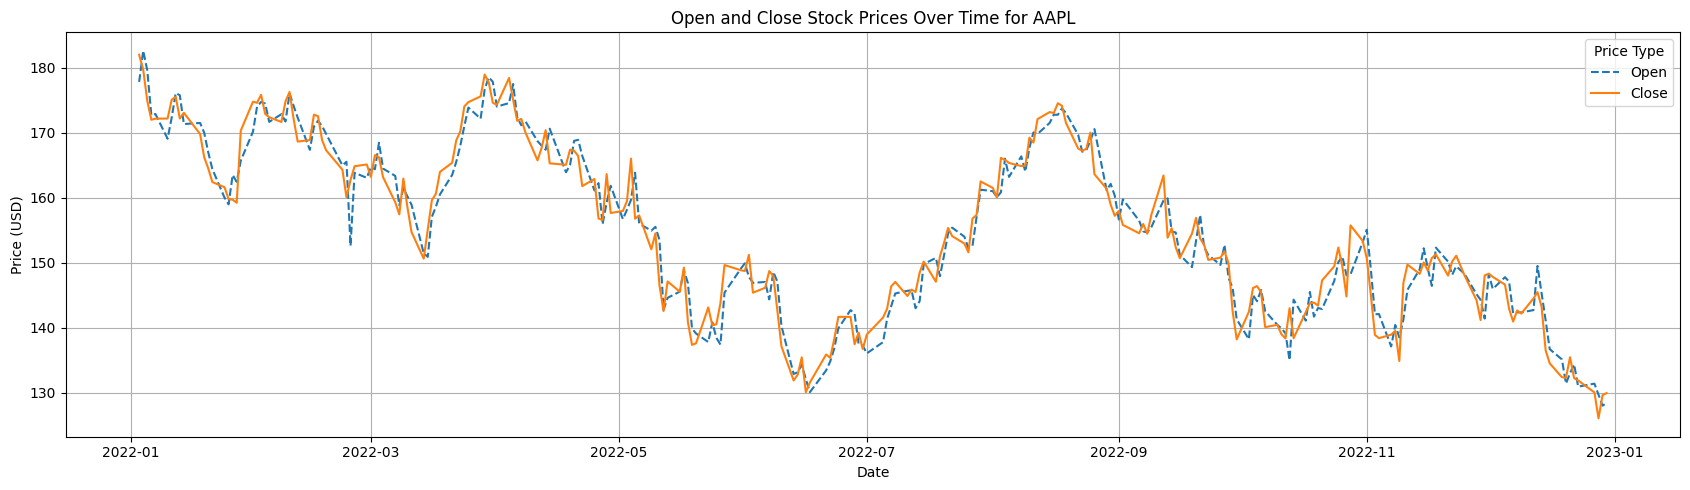

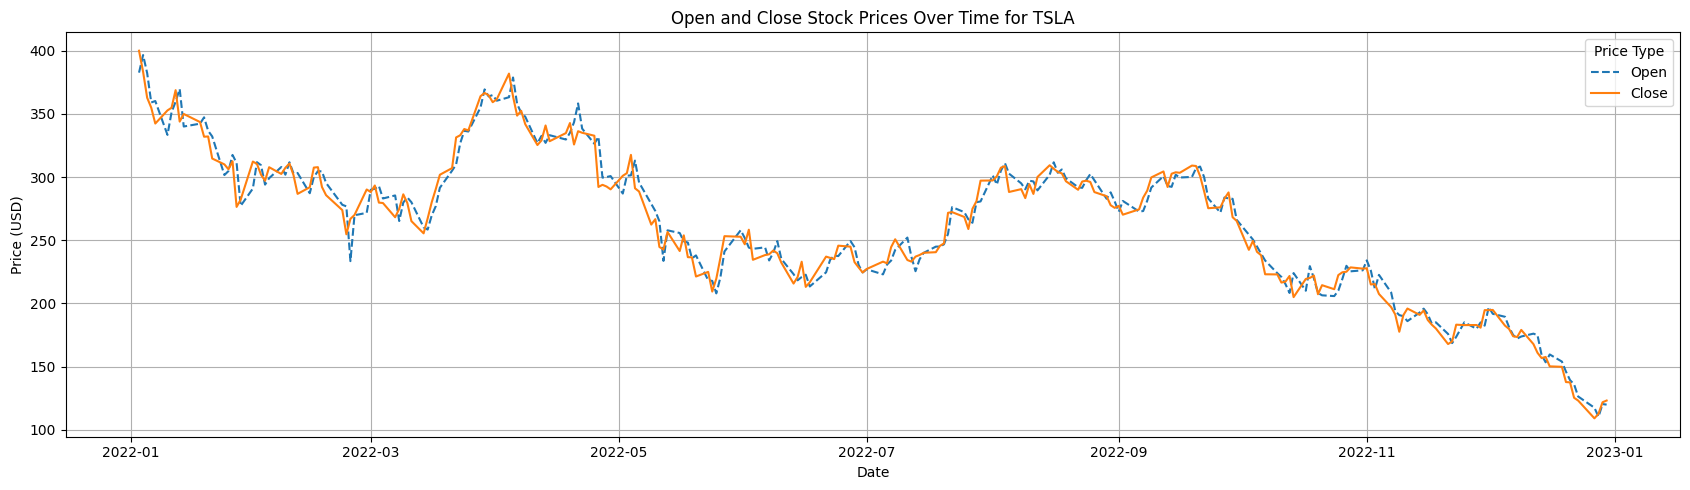

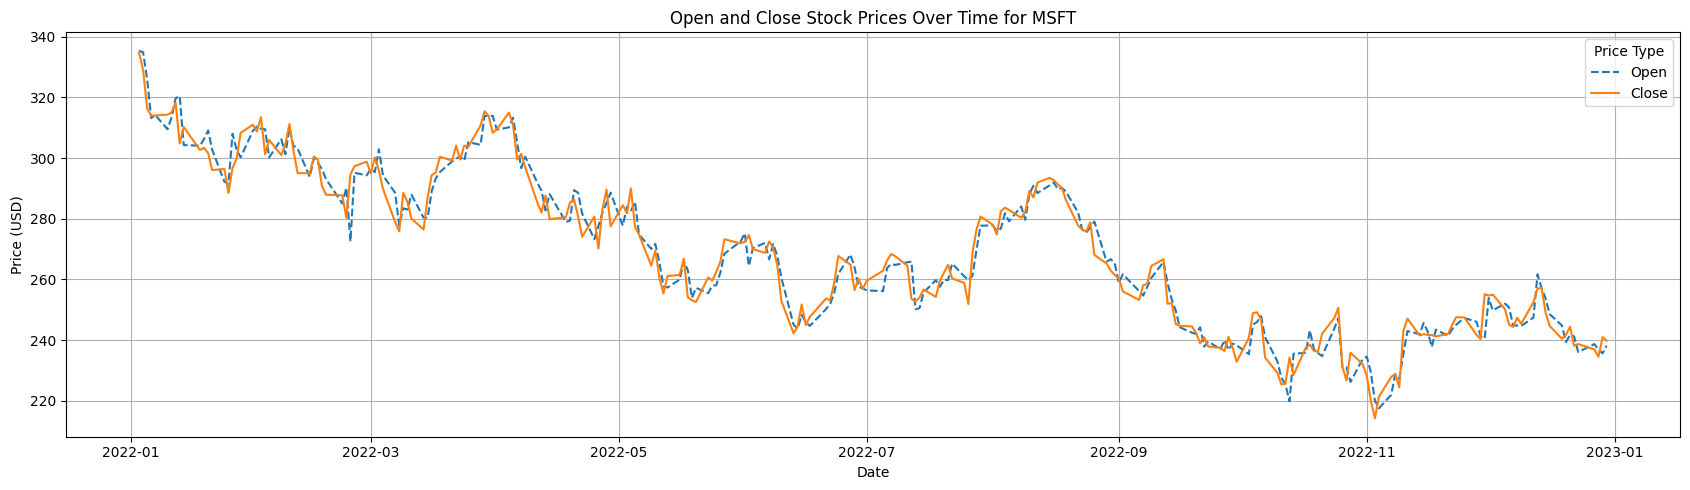

In [14]:
def plot_open_close_matplotlib(stock, df):
    plt.figure(figsize=(17, 5))    
    plt.plot(df.index, df['Open'], label='Open', linestyle='--')
    plt.plot(df.index, df['Close'], label='Close', linestyle='-')    
    plt.title(f'Open and Close Stock Prices Over Time for {stock}')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend(title='Price Type')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

for stock in stocks:
    df_plot = data[stock].loc['2022'].copy()
    plot_open_close_matplotlib(stock, df_plot)

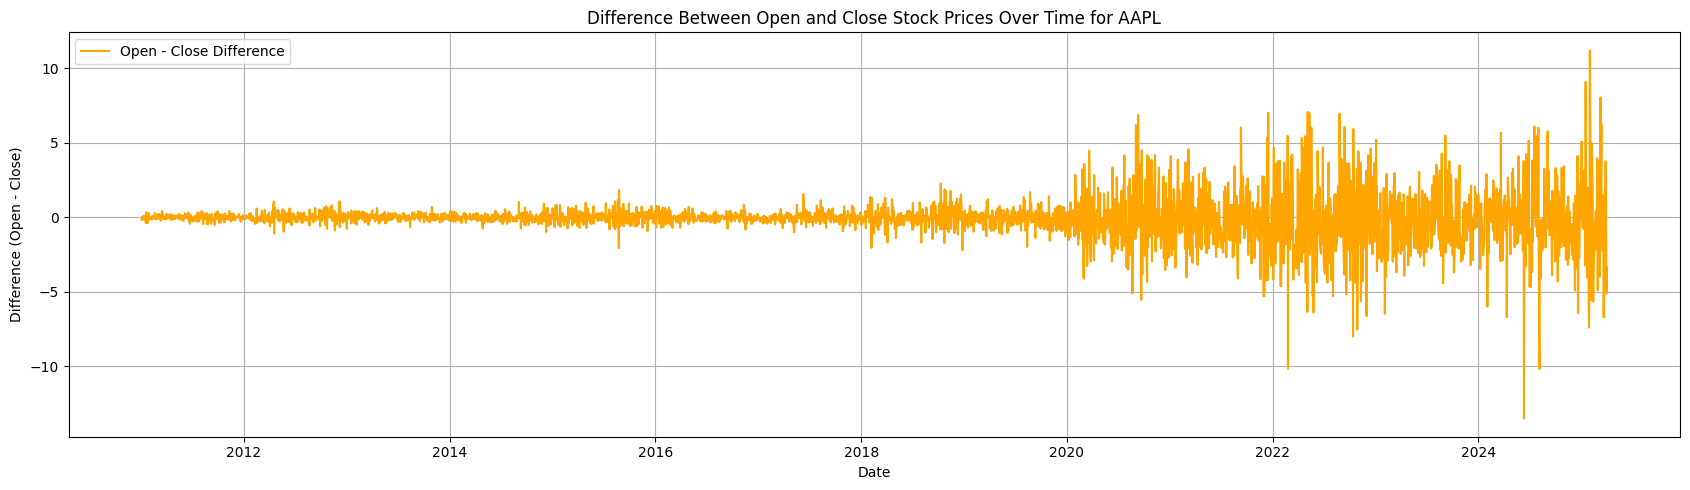

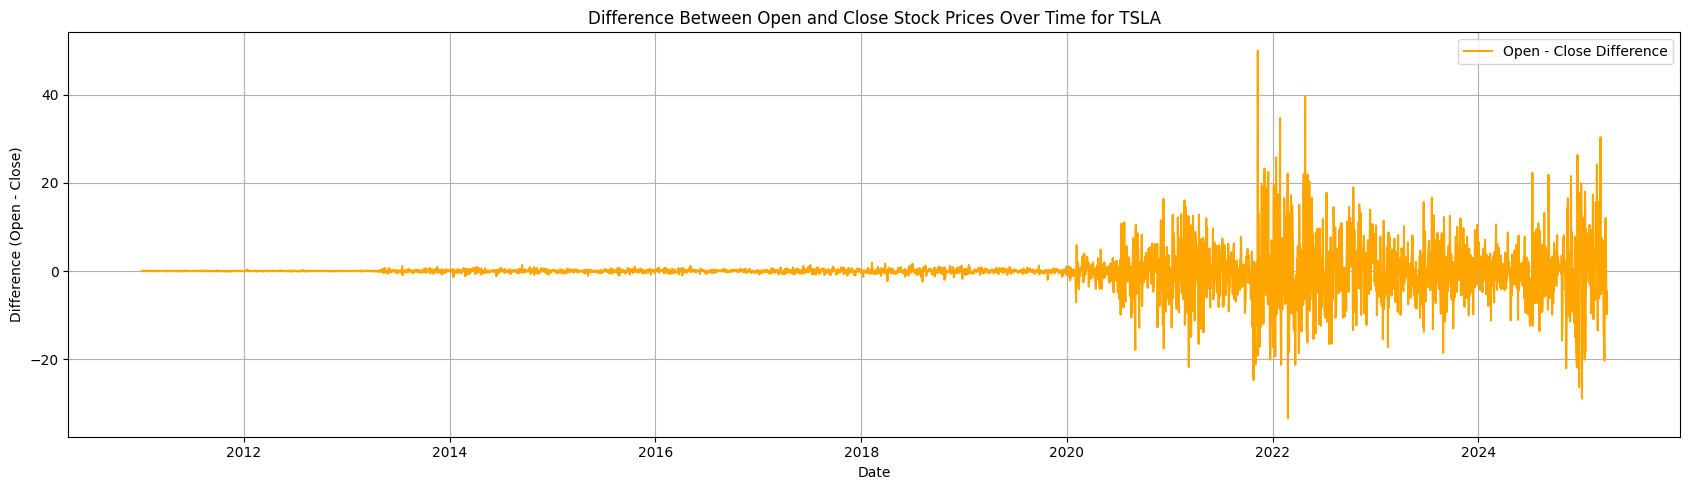

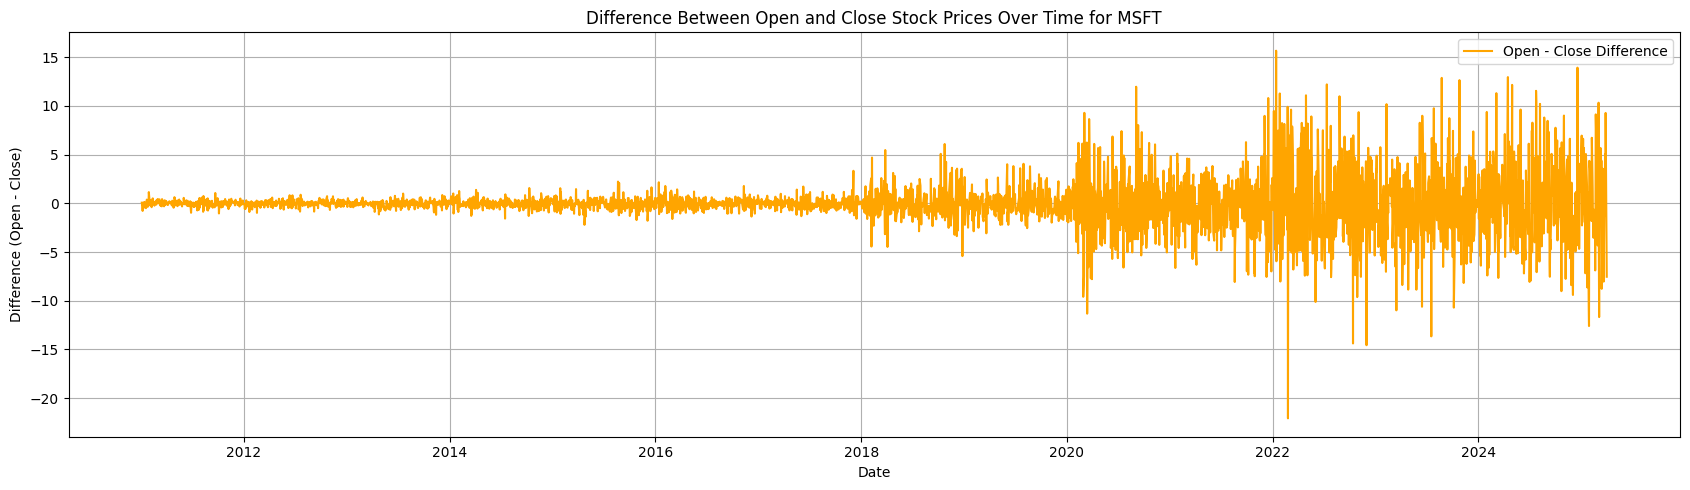

In [15]:
for stock in stocks:
    df_plot = data[stock].loc['2011':].copy()
    df_plot['difference'] = df_plot['Open'] - df_plot['Close']    
    plt.figure(figsize=(17, 5))
    plt.plot(df_plot.index, df_plot['difference'], label='Open - Close Difference', color='orange')
    plt.title(f'Difference Between Open and Close Stock Prices Over Time for {stock}')
    plt.xlabel('Date')
    plt.ylabel('Difference (Open - Close)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

The difference between open and close prices stayed relatively small before 2020 for all three stocks. After 2020, the fluctuations became more noticeable, especially for Tesla, which shows larger daily price swings. This suggests increased market activity and volatility in recent years.

In [16]:
# Candlestick Plots
for stock in stocks:
    df_plot = data[stock].loc['2022':'2022'].copy()
    fig_candle = go.Figure(data=[go.Candlestick(x=df_plot.index,
        open=df_plot['Open'],
        high=df_plot['High'],
        low=df_plot['Low'],
        close=df_plot['Close']
    )])
    fig_candle.update_layout(
        title=f'Candlestick Chart for {stock}',
        xaxis_title='Date',
        yaxis_title='Price (USD)',
        xaxis_rangeslider_visible=False
    )
    fig_candle.show()

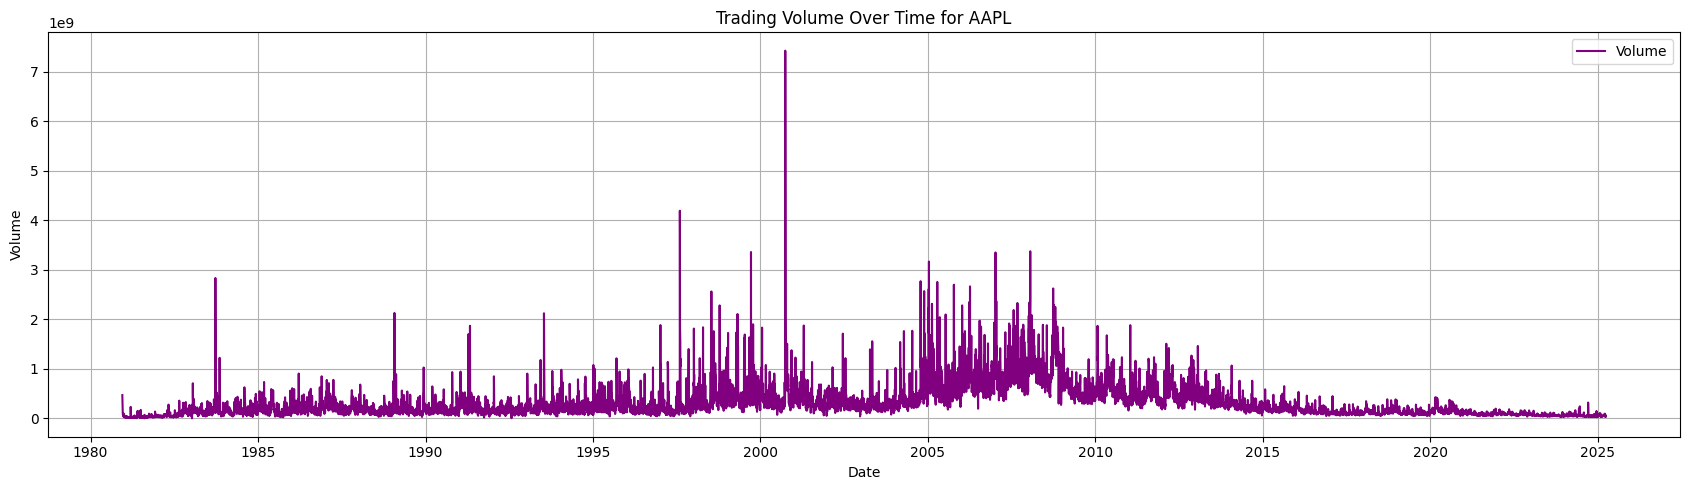

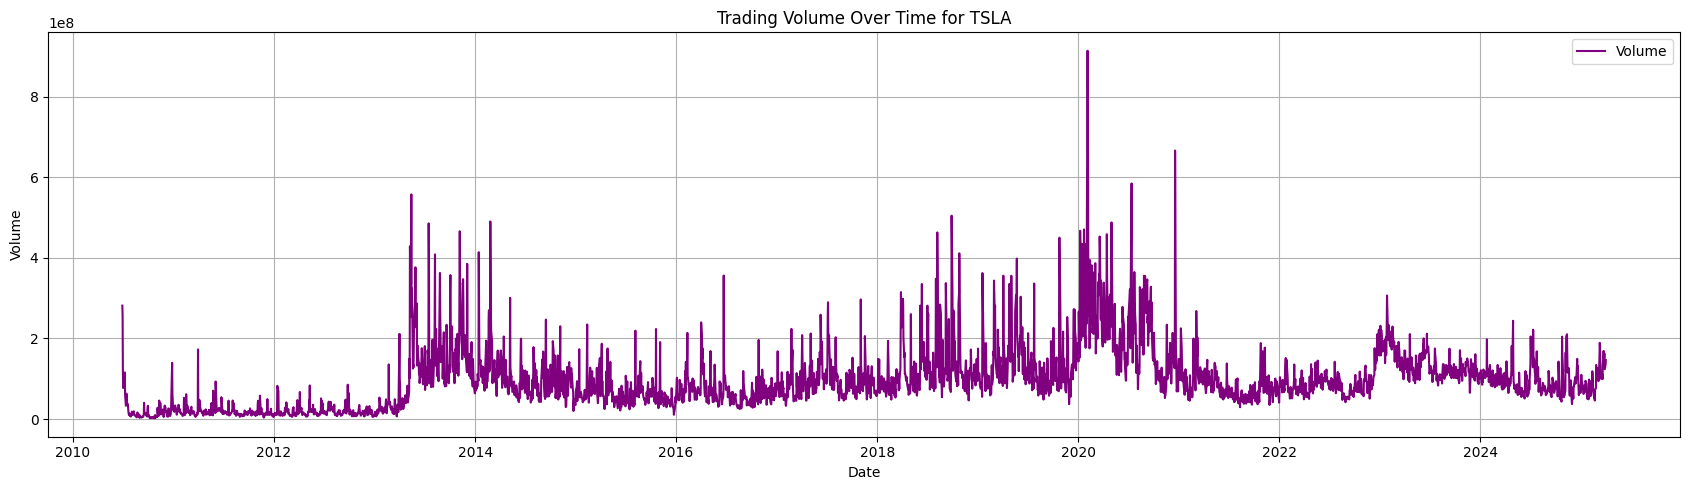

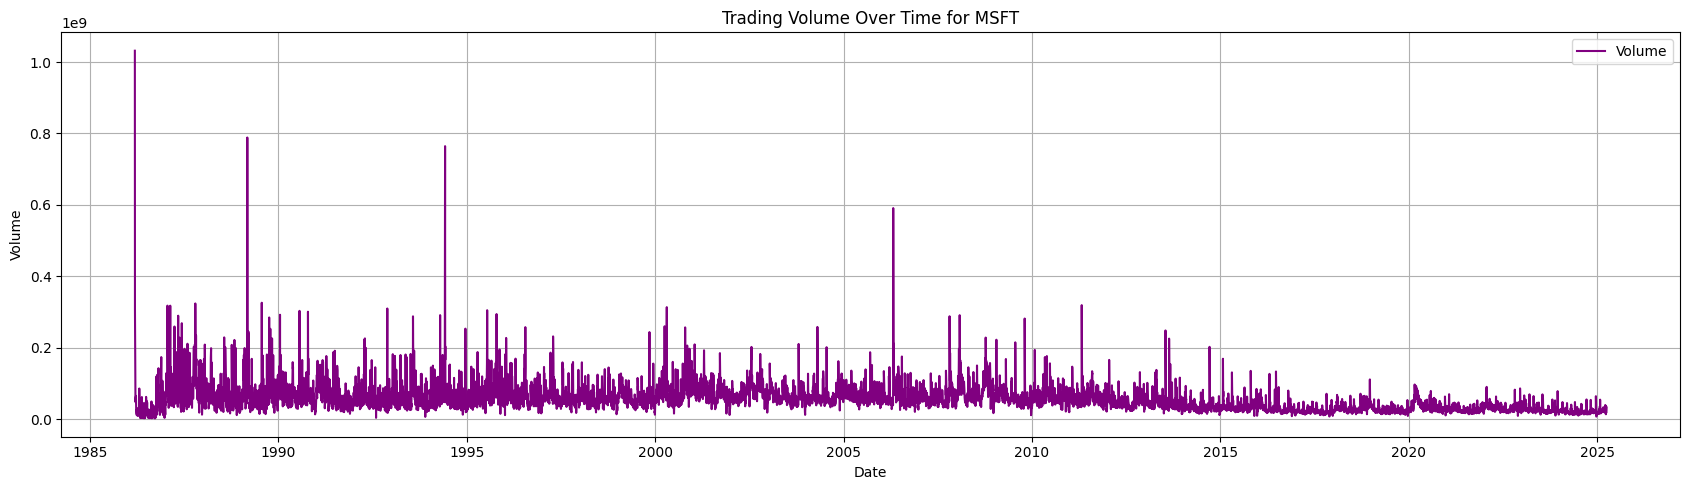

In [17]:
for stock in stocks:
    df_plot = data[stock].copy()
    plt.figure(figsize=(17, 5))
    plt.plot(df_plot.index, df_plot['Volume'], color='purple', label='Volume')
    plt.title(f'Trading Volume Over Time for {stock}')
    plt.xlabel('Date')
    plt.ylabel('Volume')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

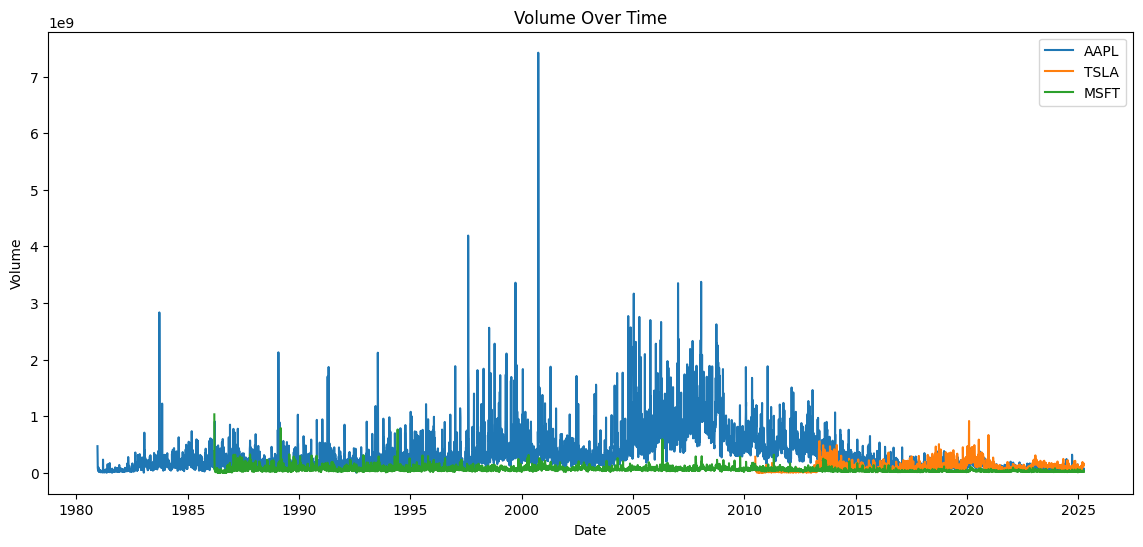

In [18]:
# Volume Spikes
plt.figure(figsize=(14, 6))
for stock in stocks:
    df = data[stock].copy()
    plt.plot(df.index, df['Volume'], label=stock)
plt.title('Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.show()

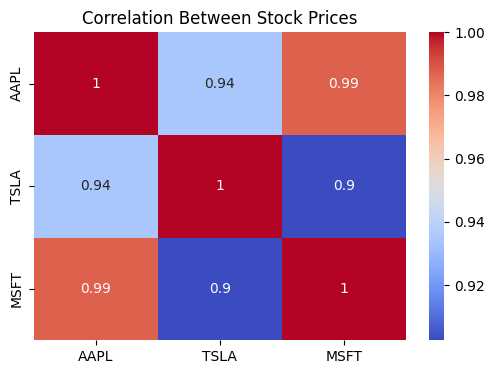

In [19]:
# Correlation heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(df_adjclose.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Stock Prices')
plt.show()

In [20]:
split_value = int(0.9*len(df_adjclose))
# Train-test split
train_data = df_adjclose[:split_value]
test_data = df_adjclose[split_value:]

print(train_data.shape, test_data.shape)

(3465, 3) (386, 3)


# ARIMA

In [21]:
# Augmented Dickey–Fuller test
for stock in stocks:
    df = df_adjclose[stock].copy()
    adf_result = adfuller(df)
    print(f'{stock} -- ADF Statistic: {adf_result[0]}, p-value: {adf_result[1]}') # If p-value > 0.05, data is not stationary


AAPL -- ADF Statistic: 0.646288345648341, p-value: 0.9887026910288893
TSLA -- ADF Statistic: -1.3258476216590933, p-value: 0.6172656122894229
MSFT -- ADF Statistic: 0.833809625538592, p-value: 0.9921627740151268


In [22]:
for stock in stocks:
    df = df_adjclose[stock].copy()
    differenced_prices = df.diff().dropna()
    adf_result = adfuller(differenced_prices)
    print(f'{stock} -- ADF Statistic: {adf_result[0]}, p-value: {adf_result[1]}')

AAPL -- ADF Statistic: -16.269976694448445, p-value: 3.49595948664777e-29
TSLA -- ADF Statistic: -11.153791524447161, p-value: 2.8995868929232345e-20
MSFT -- ADF Statistic: -11.395568060848264, p-value: 7.874052811391636e-21


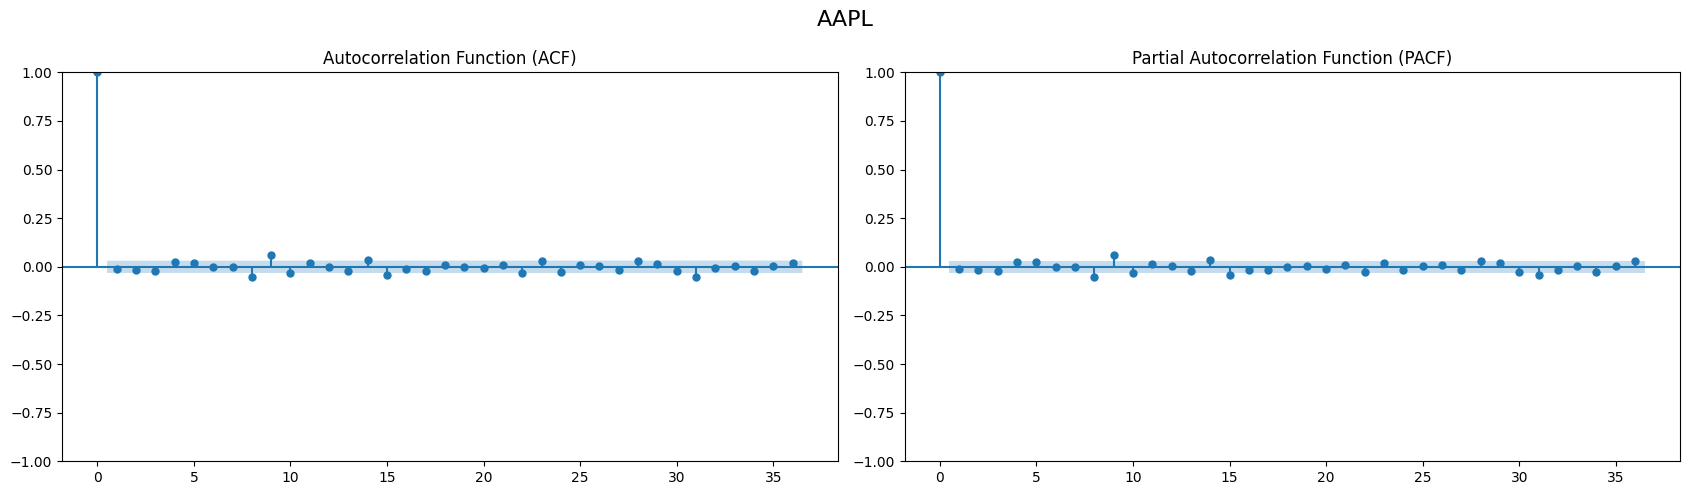

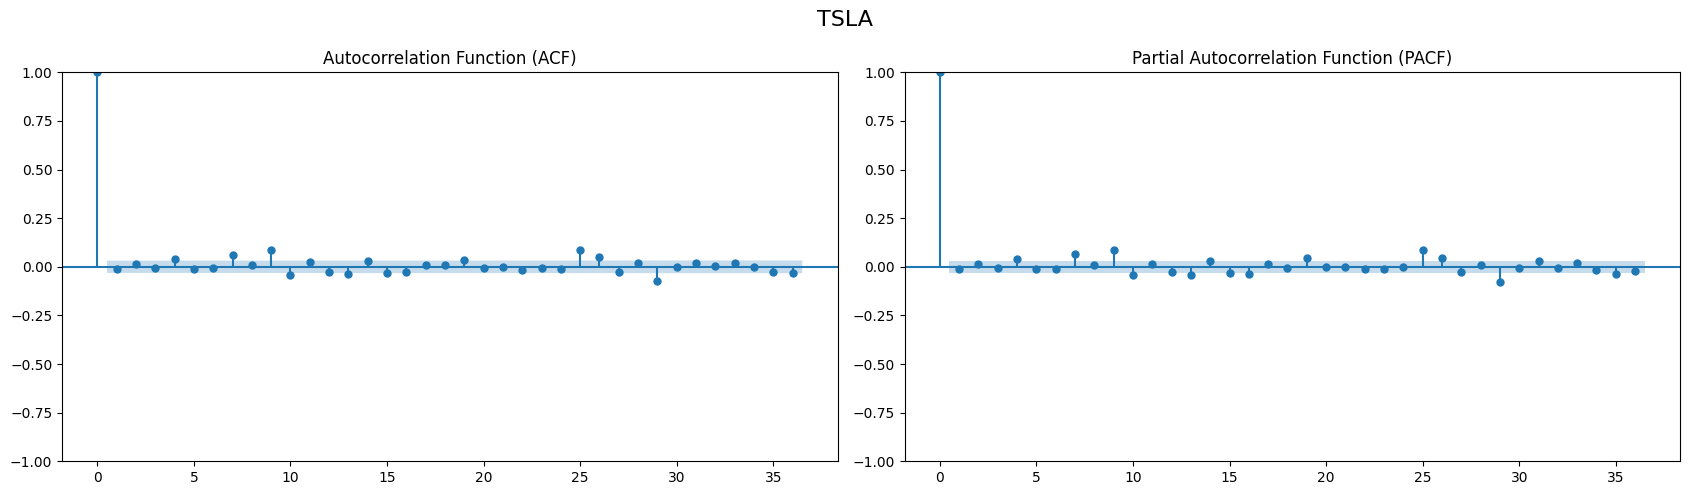

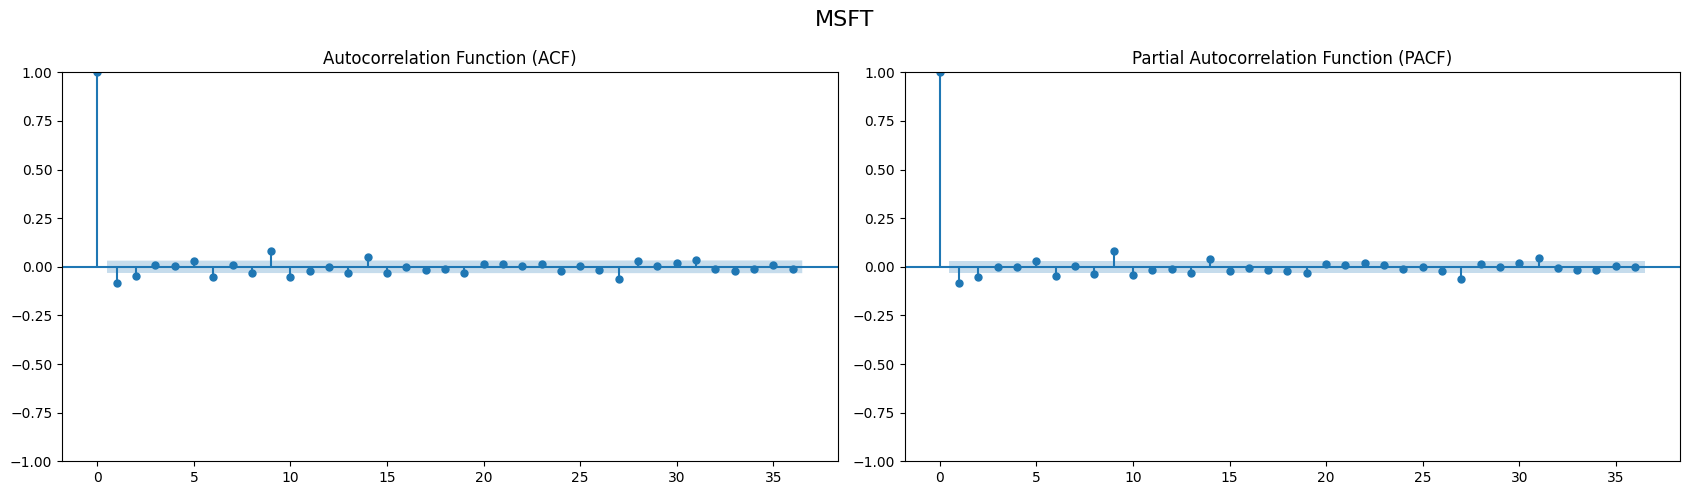

In [23]:
# Autocorrelation and Partial Autocorrelation plots
for stock in stocks:
    df = df_adjclose[stock].copy()
    differenced_prices = df.diff().dropna()
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 5))
    # ACF plot to find q
    plot_acf(differenced_prices, ax=ax1)
    ax1.set_title('Autocorrelation Function (ACF)')
    
    # PACF plot to find p
    plot_pacf(differenced_prices, ax=ax2)
    ax2.set_title('Partial Autocorrelation Function (PACF)')
    fig.suptitle(f'{stock}', fontsize=16)
    plt.tight_layout()
    plt.show()

In [24]:
# check best order using auto arima
model_auto_arima_params = {}
for stock in stocks:
    try:
        df = df_adjclose[stock].copy()
        model = auto_arima(df, seasonal=False, stepwise=True, suppress_warnings=True, error_action="ignore", trace=False)
        model_auto_arima_params[stock] = {
            "model": model,
            "aic": model.aic(),
            "order": model.order
        }
        print(f"{stock}: Best ARIMA order = {model.order}, AIC = {model.aic()}")
    except:
        continue

AAPL: Best ARIMA order = (0, 1, 0), AIC = 14777.839032906244
TSLA: Best ARIMA order = (2, 1, 2), AIC = 23825.003007026797
MSFT: Best ARIMA order = (1, 1, 2), AIC = 19243.601423043052


100%|██████████| 386/386 [00:24<00:00, 15.73it/s]


AAPL: ARIMA -> order = (0, 1, 0), AIC = 14777.01, MAE: 2.1075, RMSE: 2.9509


 65%|██████▍   | 250/386 [11:08<06:02,  2.67s/it]/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

 67%|██████▋   | 260/386 [11:39<06:24,  3.05s/it]/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

 75%|███████▌  | 290/386 [12:45<03:29,  2.18s/it]/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

 76%|███████▌  | 294/386 [12:54<03:10,  2.07s/it]/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

 76%|███████▋  | 295/386 [12:58<03:44,  2.46s/it]/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Lik

TSLA: ARIMA -> order = (2, 1, 2), AIC = 23815.11, MAE: 7.0312, RMSE: 10.1512


100%|██████████| 386/386 [06:36<00:00,  1.03s/it]


MSFT: ARIMA -> order = (1, 1, 2), AIC = 19238.84, MAE: 3.8496, RMSE: 5.2723
AAPL: ARIMA -> order = (0, 1, 0), AIC = 14777.01, MAE: 2.1075, RMSE: 2.9509


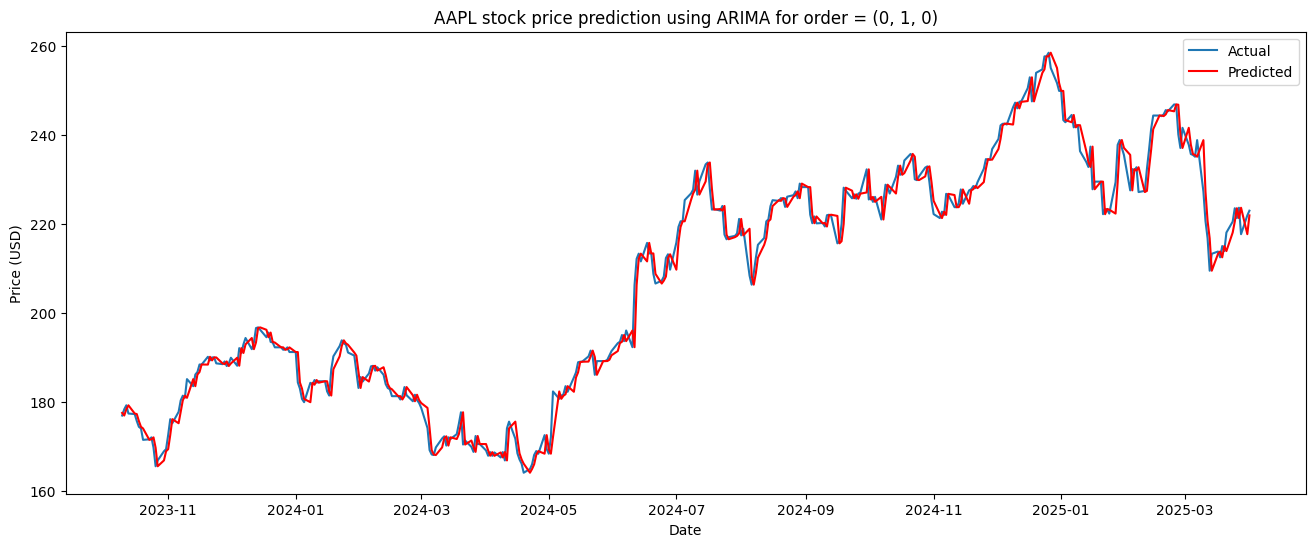

TSLA: ARIMA -> order = (2, 1, 2), AIC = 23815.11, MAE: 7.0312, RMSE: 10.1512


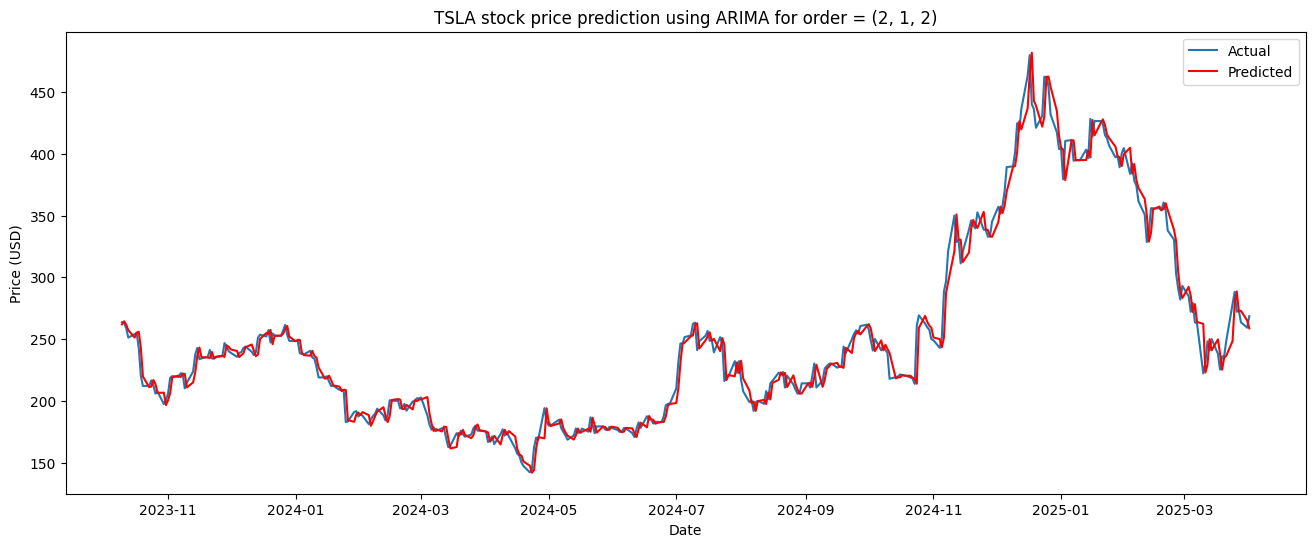

MSFT: ARIMA -> order = (1, 1, 2), AIC = 19238.84, MAE: 3.8496, RMSE: 5.2723


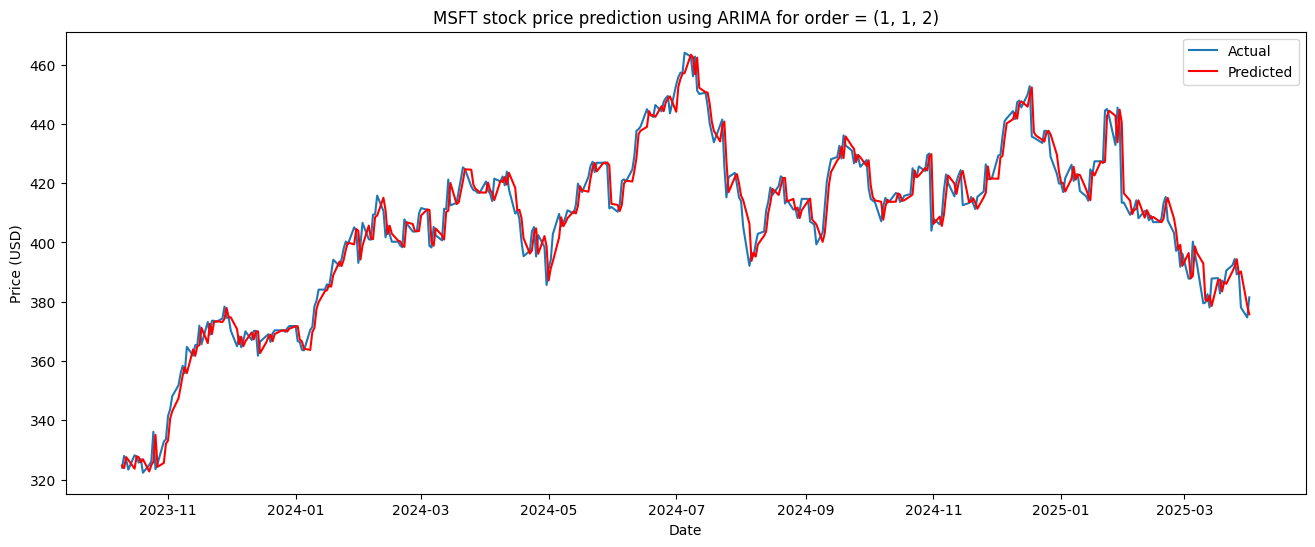

In [25]:
# Train ARIMA model using the order suggested by auto_arima
model_auto_arima = {}

for stock in stocks:
    order = model_auto_arima_params[stock]['order']
    train = list(train_data[stock].copy())
    test = list(test_data[stock].copy())
    y_pred = []

    try:
        for i in tqdm(range(len(test))):
            model = ARIMA(train, order=order)
            model_fit = model.fit()
            forecast = model_fit.forecast()
            y_pred.append(forecast[0])
            train.append(test[i])

        mae = mean_absolute_error(test, y_pred)
        rmse = np.sqrt(mean_squared_error(test, y_pred))
        
        model_fit.summary()
        model_auto_arima[stock] = {
            "model": model_fit,
            "y_test_index": test_data[stock].index,
            "y_test": test,
            "y_pred": y_pred,
            "aic": round(model_fit.aic, 2),
            "mae": round(mae, 4),
            "rmse": round(rmse, 4),
            "order": order
        }
        print(f"{stock}: ARIMA -> order = {order}, AIC = {model_fit.aic:.2f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}")
    except:
        continue

for stock in stocks:
    model = model_auto_arima[stock]
    print(f"{stock}: ARIMA -> order = {model['order']}, AIC = {model['aic']}, MAE: {model['mae']}, RMSE: {model['rmse']}")
    plt.figure(figsize=(16, 6))
    plt.plot(model['y_test_index'], model['y_test'], label='Actual')
    plt.plot(model['y_test_index'], model['y_pred'], label='Predicted', color='red')
    plt.title(f'''{stock} stock price prediction using ARIMA for order = {model['order']}''')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.show()

100%|██████████| 386/386 [02:58<00:00,  2.16it/s]


AAPL: ARIMA -> order = (5, 1, 0), AIC = 14779.92, MAE: 2.1307, RMSE: 2.9685


100%|██████████| 386/386 [03:03<00:00,  2.10it/s]


TSLA: ARIMA -> order = (5, 1, 0), AIC = 23852.19, MAE: 7.0017, RMSE: 10.1987


100%|██████████| 386/386 [03:23<00:00,  1.90it/s]


MSFT: ARIMA -> order = (5, 1, 0), AIC = 19248.09, MAE: 3.8598, RMSE: 5.2827


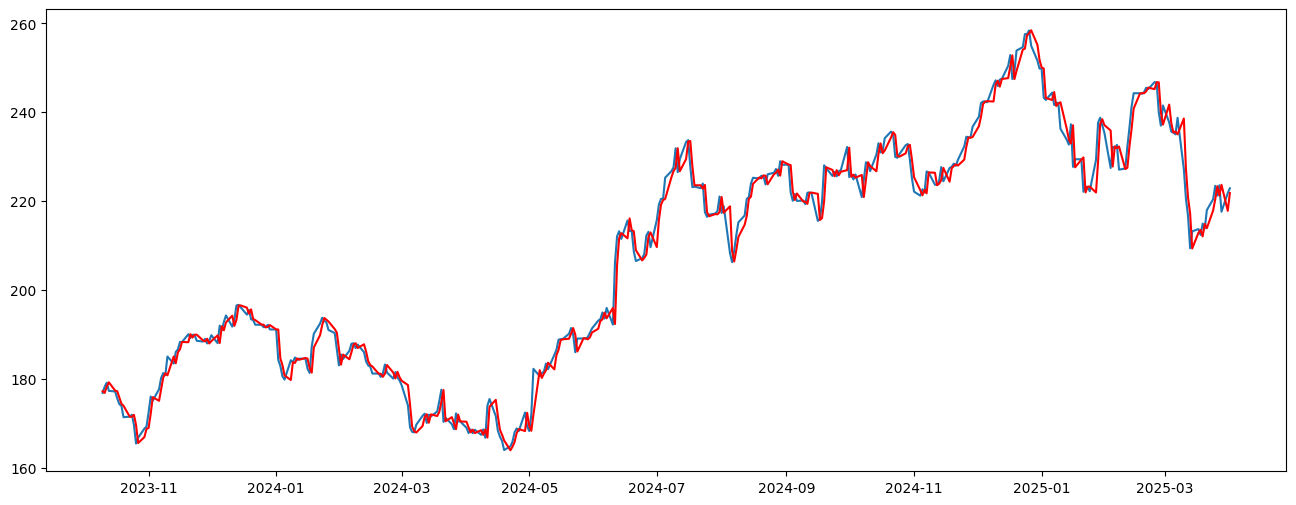

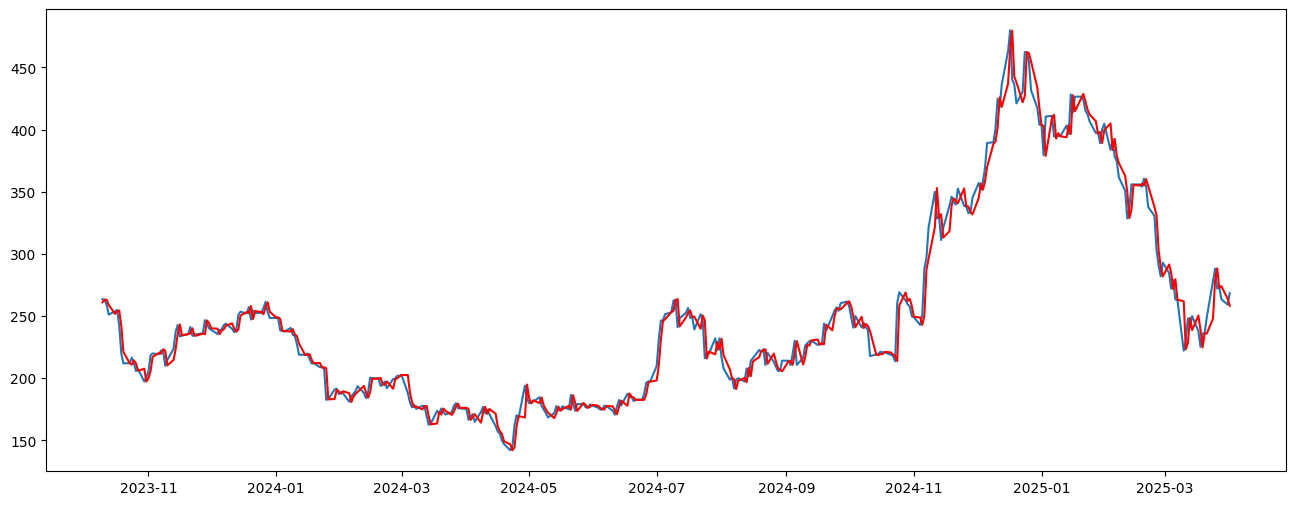

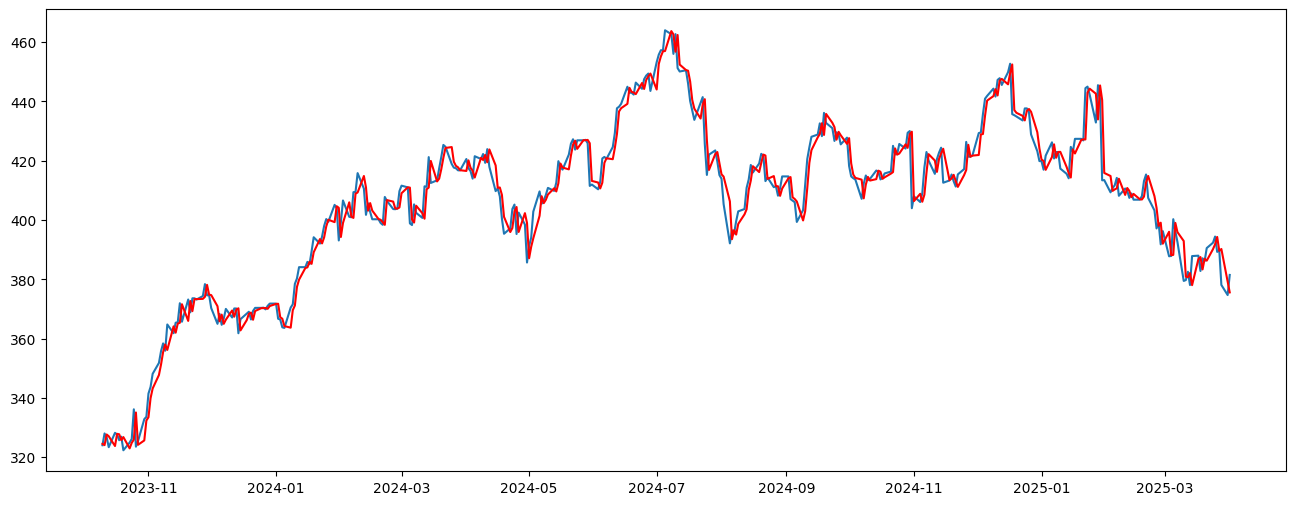

In [26]:
# Train ARIMA model using the order (p=5, d=1, q=0)
model_arima = {}
for stock in stocks:
    train = list(train_data[stock].copy())
    test = list(test_data[stock].copy())
    y_pred = []
    
    try:
        for i in tqdm(range(len(test))):
            model = ARIMA(train, order=(5, 1, 0))
            model_fit = model.fit()
            forecast = model_fit.forecast()
            y_pred.append(forecast[0])
            train.append(test[i])
            
        mae = mean_absolute_error(test, y_pred)
        rmse = np.sqrt(mean_squared_error(test, y_pred))
        
        model_fit.summary()
        model_arima[stock] = {
            "model": model_fit,
            "y_test_index": test_data[stock].index,
            "y_test": test,
            "y_pred": y_pred,
            "aic": round(model_fit.aic, 2),
            "mae": round(mae, 4),
            "rmse": round(rmse, 4),
            "order": (5, 1, 0)
        }
        print(f"{stock}: ARIMA -> order = (5, 1, 0), AIC = {model_fit.aic:.2f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}")

        plt.figure(figsize=(16, 6))
        plt.plot(test_data[stock].index, test, label='Actual')
        plt.plot(test_data[stock].index, y_pred, label='Predicted', color='red')
        plt.title(f'''{stock} stock price prediction using ARIMA for order = {model['order']}''')
        plt.xlabel('Date')
        plt.ylabel('Price (USD)')
        plt.legend()
        plt.show()
    except:
        continue

# PROPHET

22:10:16 - cmdstanpy - INFO - Chain [1] start processing
22:10:17 - cmdstanpy - INFO - Chain [1] done processing


AAPL: PROPHET -> MAE: 28.4666, RMSE: 34.0268


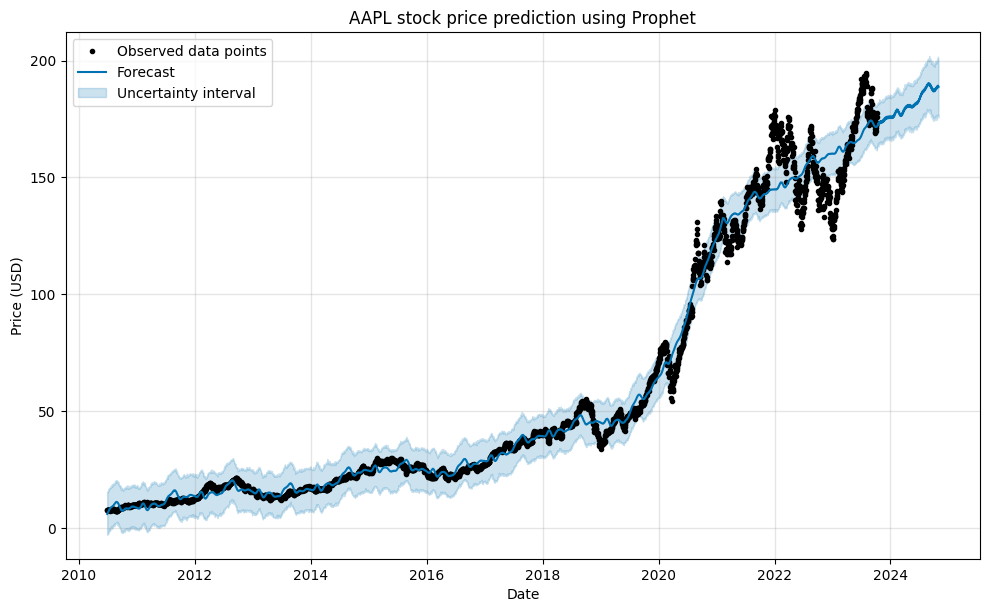

22:10:18 - cmdstanpy - INFO - Chain [1] start processing
22:10:19 - cmdstanpy - INFO - Chain [1] done processing


TSLA: PROPHET -> MAE: 56.1899, RMSE: 80.9238


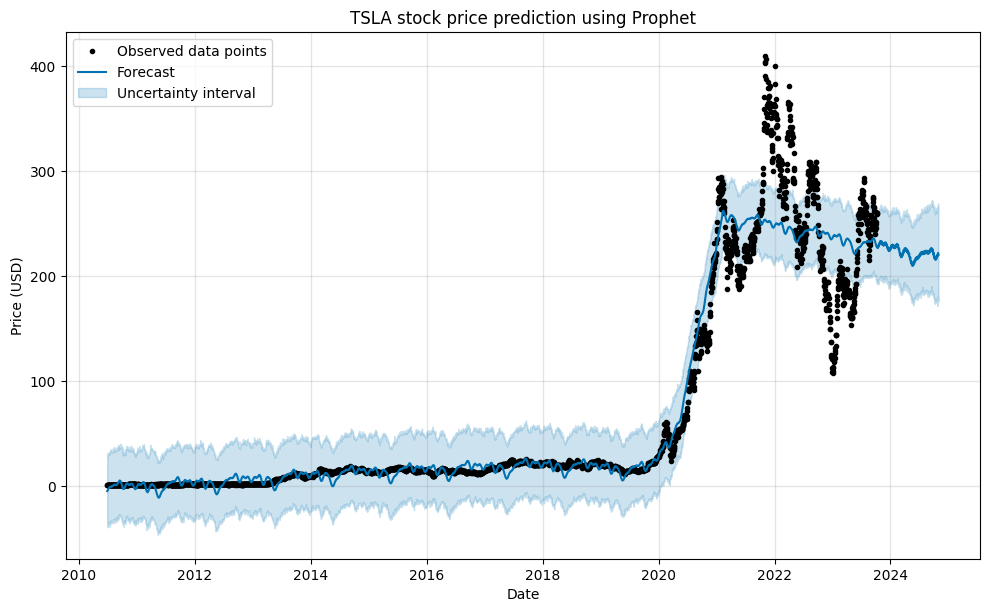

22:10:20 - cmdstanpy - INFO - Chain [1] start processing
22:10:21 - cmdstanpy - INFO - Chain [1] done processing


MSFT: PROPHET -> MAE: 94.8161, RMSE: 98.0584


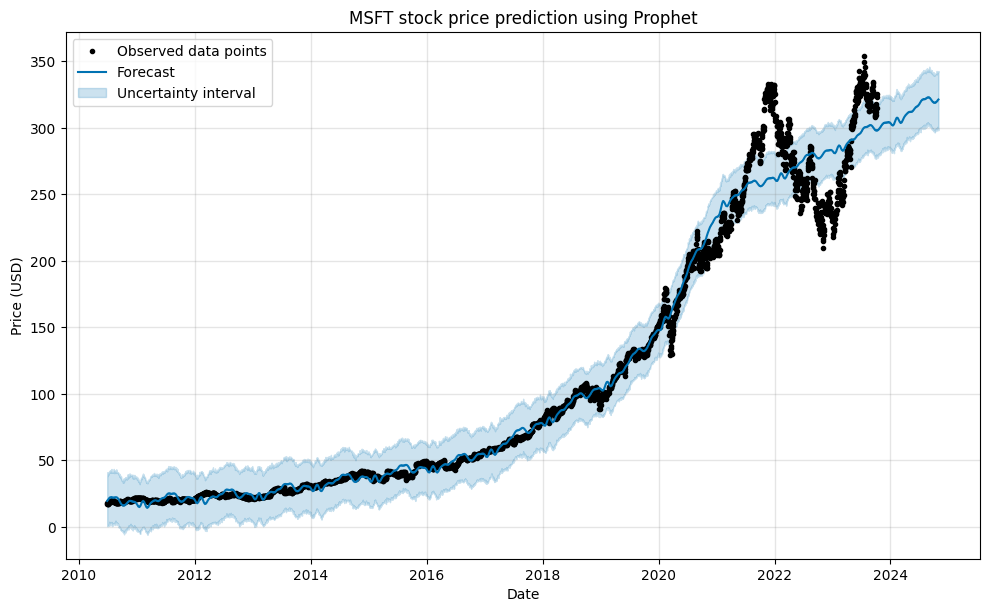

In [27]:
model_prophet = {}
for stock in stocks:
    df_train = train_data[stock].copy().reset_index().rename(columns={'index': 'ds', stock: 'y'})
    df_test = test_data[stock].copy().reset_index().rename(columns={'index': 'ds', stock: 'y'})
    
    model = Prophet()
    model.fit(df_train)
    
    future = model.make_future_dataframe(periods=len(df_test))
    forecast = model.predict(future)
    yhat = forecast['yhat'].tail(len(df_test))
    
    mae = mean_absolute_error(df_test["y"], yhat)
    rmse = np.sqrt(mean_squared_error(df_test["y"], yhat))
    print(f"{stock}: PROPHET -> MAE: {mae:.4f}, RMSE: {rmse:.4f}")

    model.plot(forecast)
    plt.title(f'{stock} stock price prediction using Prophet')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.show()

    model_prophet[stock] = {
        "model": model,
        "y_test_index": df_test['ds'].values,
        "y_test": df_test['y'].values,
        "y_pred": yhat.values,
        "mae": round(mae, 4),
        "rmse": round(rmse, 4),
        'forecast': forecast
    }

In [28]:
model_prophet_hyperparameters = {}
# hyperparameters to test prophet
changepoint_scales = [0.01, 0.05, 0.1, 0.5]
seasonality_scales = [1, 5, 10, 20]

for stock in stocks:
    df_train = (train_data[stock].copy().reset_index().rename(columns={"index": "ds", stock: "y"}))
    df_test = (test_data[stock].copy().reset_index().rename(columns={"index": "ds", stock: "y"}))

    best_rmse, best_mae = float("inf"), float("inf")
    best_params = {}
    best_model, best_yhat, best_forecast = None, None, None

    print(f"\nTuning Prophet hyperparameters for {stock}")

    for cp_scale in changepoint_scales:
        for s_scale in seasonality_scales:
            model = Prophet(changepoint_prior_scale=cp_scale, seasonality_prior_scale=s_scale)
            model.fit(df_train)

            future = model.make_future_dataframe(periods=len(df_test))
            forecast = model.predict(future)
            yhat = forecast["yhat"].tail(len(df_test))

            mae = mean_absolute_error(df_test["y"], yhat)
            rmse = np.sqrt(mean_squared_error(df_test["y"], yhat))

            print(f"Params: cp_scale={cp_scale}, s_scale={s_scale}, MAE: {mae:.2f}, RMSE: {rmse:.2f}")

            if rmse < best_rmse:
                best_rmse = rmse
                best_mae = mae
                best_params = {"changepoint_prior_scale": cp_scale, "seasonality_prior_scale": s_scale}
                best_model = model
                best_yhat = yhat
                best_forecast = forecast

    print(f"{stock}: PROPHET -> Params: {best_params},  MAE: {best_mae:.4f}, RMSE: {best_rmse:.4f}")
    model_prophet_hyperparameters[stock] = {
        "model": best_model,
        "y_test_index": df_test['ds'].values,
        "y_test": df_test['y'].values,
        "y_pred": best_yhat.values,
        "mae": round(best_mae, 4),
        "rmse": round(best_rmse, 4),
        "forecast": best_forecast,
        "params": best_params
    }

22:10:23 - cmdstanpy - INFO - Chain [1] start processing



Tuning Prophet hyperparameters for AAPL


22:10:23 - cmdstanpy - INFO - Chain [1] done processing
22:10:24 - cmdstanpy - INFO - Chain [1] start processing


Params: cp_scale=0.01, s_scale=1, MAE: 24.99, RMSE: 30.12


22:10:25 - cmdstanpy - INFO - Chain [1] done processing
22:10:25 - cmdstanpy - INFO - Chain [1] start processing


...

Params: cp_scale=0.5, s_scale=5, MAE: 99.19, RMSE: 102.42


22:11:51 - cmdstanpy - INFO - Chain [1] done processing
22:11:52 - cmdstanpy - INFO - Chain [1] start processing


Params: cp_scale=0.5, s_scale=10, MAE: 99.31, RMSE: 102.55


22:11:54 - cmdstanpy - INFO - Chain [1] done processing


Params: cp_scale=0.5, s_scale=20, MAE: 99.26, RMSE: 102.50
MSFT: PROPHET -> Params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 10},  MAE: 84.5508, RMSE: 88.0340


AAPL: PROPHET with hyperparameters -> Params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1},  MAE: 24.9853, RMSE: 30.1153


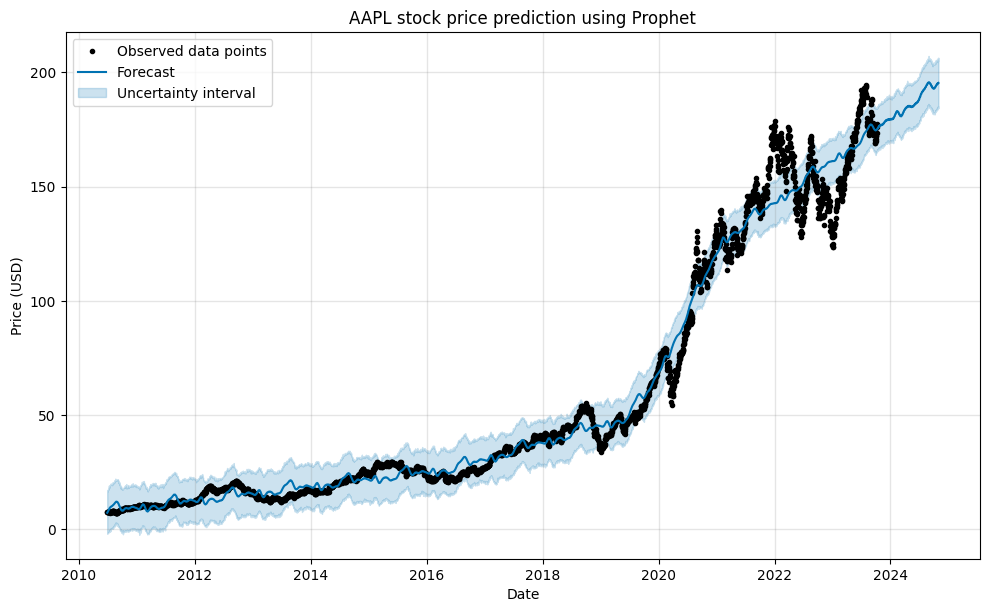

TSLA: PROPHET with hyperparameters -> Params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 20},  MAE: 59.3475, RMSE: 73.3061


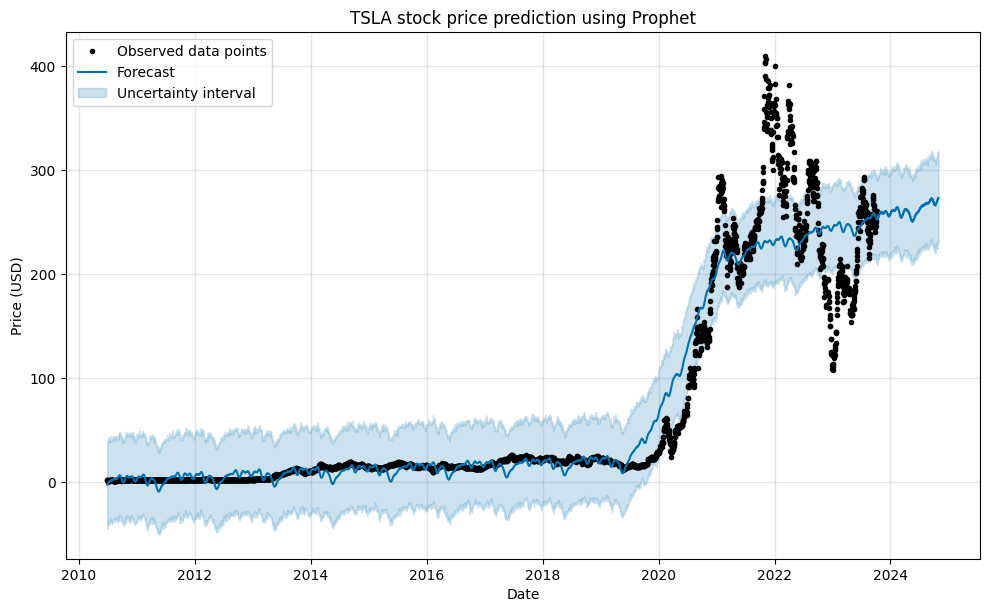

MSFT: PROPHET with hyperparameters -> Params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 10},  MAE: 84.5508, RMSE: 88.034


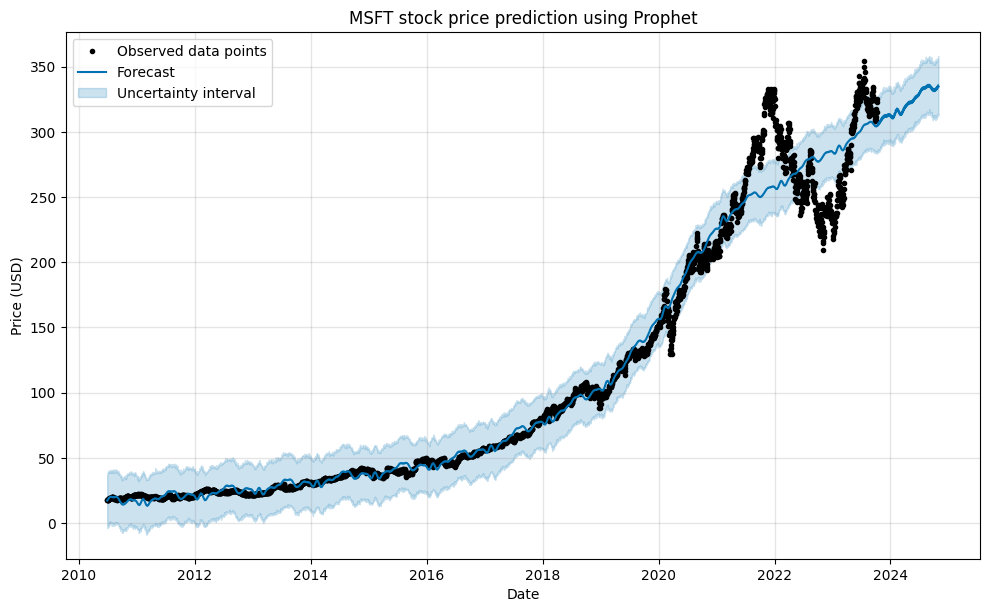

In [29]:
# plot Prophet results with hyperparameters
for stock in stocks:
    model = model_prophet_hyperparameters[stock]
    print(f"{stock}: PROPHET with hyperparameters -> Params: {model['params']},  MAE: {model['mae']}, RMSE: {model['rmse']}")
    model['model'].plot(model['forecast'])
    plt.title(f'{stock} stock price prediction using Prophet')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.show()

# LSTM

In [30]:
def create_sequences(data, seq_length):
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i:i+seq_length, 0])
        y.append(data[i+seq_length, 0])
    return np.array(x), np.array(y)

def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(hp.Int('seq_length', min_value=30, max_value=120, step=30), 1)))
    model.add(LSTM(units=hp.Int('units_1', min_value=32, max_value=128, step=32), return_sequences=True))
    model.add(Dropout(rate=hp.Float('dropout_1', 0.1, 0.5, step=0.1)))
    model.add(LSTM(units=hp.Int('units_2', min_value=32, max_value=128, step=32), return_sequences=False))
    model.add(Dropout(rate=hp.Float('dropout_2', 0.1, 0.5, step=0.1)))
    model.add(Dense(units=hp.Int('dense_units', 16, 64, step=16)))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    return model

In [31]:
model_lstm = {}

for stock in stocks:    
    scaler = MinMaxScaler(feature_range=(0, 1))
    df_scaled = scaler.fit_transform(df_adjclose[stock].values.reshape(-1, 1))
    
    default_seq_length = 60
    x, y = create_sequences(df_scaled, default_seq_length)

    X_train, y_train = x[:split_value - default_seq_length], y[:split_value - default_seq_length]
    X_test, y_test = x[split_value - default_seq_length:], y[split_value - default_seq_length:]

    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

    tuner = kt.RandomSearch(build_model, objective='val_loss', max_trials=5, executions_per_trial=1, directory='lstm_tuner', project_name=f'lstm_{stock}', overwrite=True)

    callbacks = [EarlyStopping(monitor='val_loss', patience=5), ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, verbose=1)]

    tuner.search(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, callbacks=callbacks, verbose=1)

    best_hp = tuner.get_best_hyperparameters(1)[0]
    best_seq_length = best_hp.get('seq_length')

    x, y = create_sequences(df_scaled, best_seq_length)
    X_train, y_train = x[:split_value - best_seq_length], y[:split_value - best_seq_length]
    X_test, y_test = x[split_value - best_seq_length:], y[split_value - best_seq_length:]
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

    model = tuner.hypermodel.build(best_hp)
    history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, callbacks=callbacks, verbose=0)

    y_pred_scaled = model.predict(X_test)
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

    mae = mean_absolute_error(y_test_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))

    model_lstm[stock] = {
        "model": model,
        "y_test_index": test_data[stock].index,
        "y_test": y_test_actual.reshape(-1),
        "y_pred": y_pred.reshape(-1),
        "mae": round(mae, 4),
        "rmse": round(rmse, 4),
        "history": history,
        "scaler": scaler,
        "best_hp": best_hp
    }

Trial 5 Complete [00h 01m 52s]
val_loss: 0.0004024445661343634

Best val_loss So Far: 0.0004024445661343634
Total elapsed time: 00h 07m 36s

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 14: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 17: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 20: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.

Epoch 23: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step


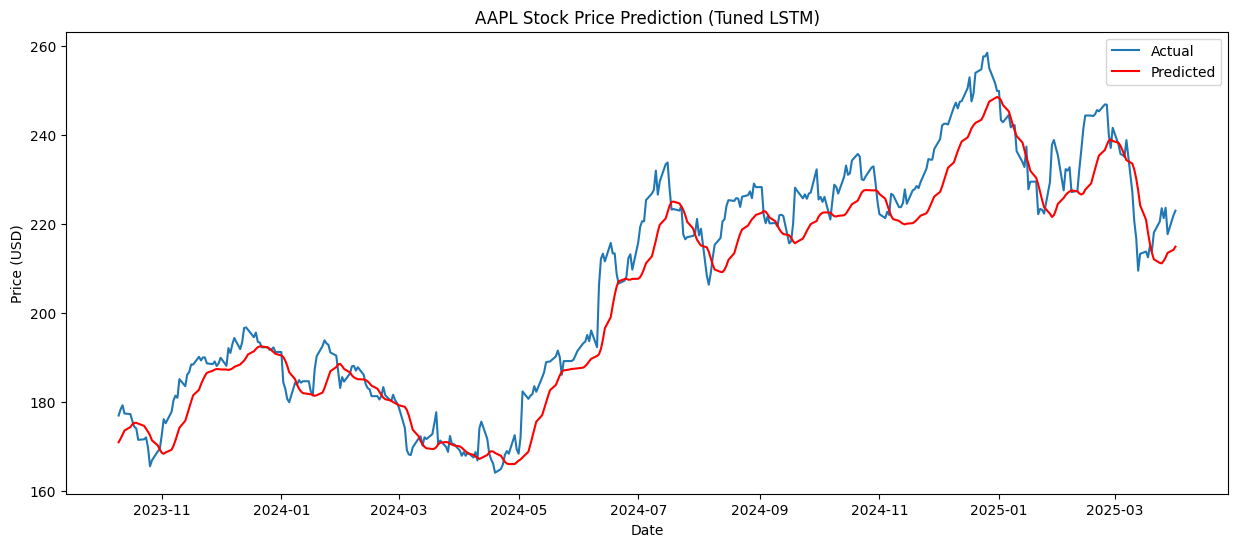

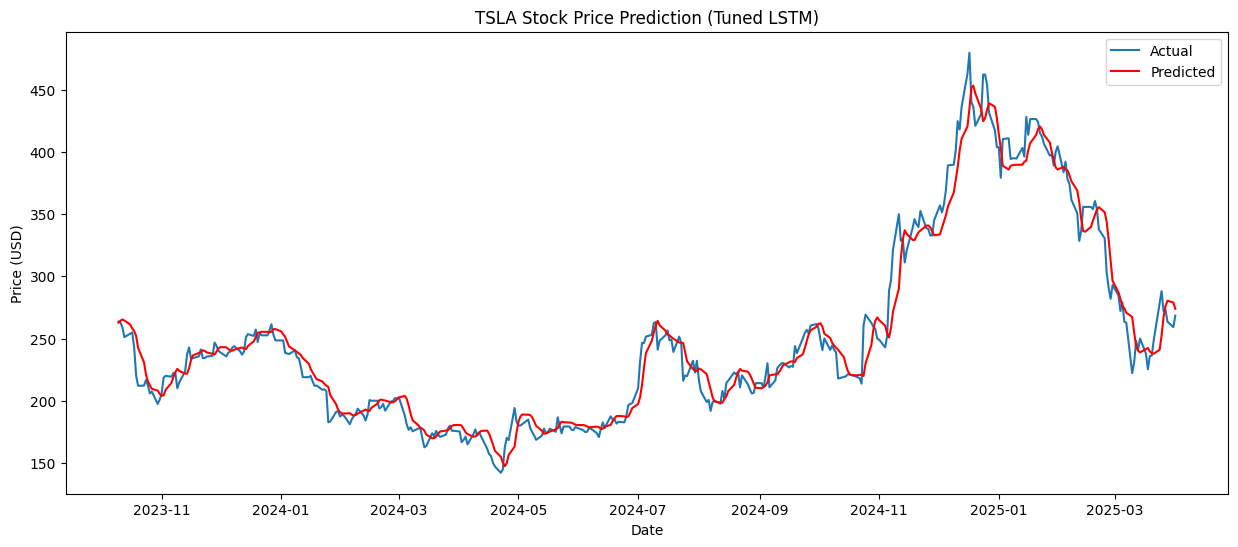

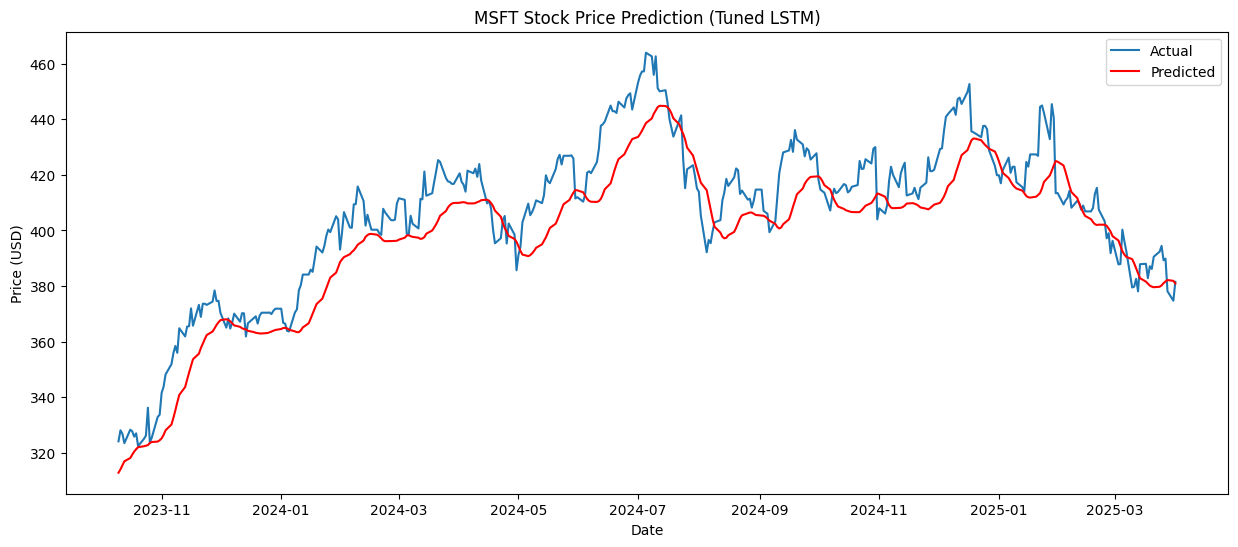

In [32]:
# plot results of LSTM
for stock in stocks:
    plt.figure(figsize=(15, 6))
    plt.plot(model_lstm[stock]['y_test_index'], model_lstm[stock]['y_test'], label='Actual')
    plt.plot(model_lstm[stock]['y_test_index'], model_lstm[stock]['y_pred'], label='Predicted', color='red')
    plt.title(f'{stock} Stock Price Prediction (Tuned LSTM)')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.show()

# EVALUATION

In [33]:
results = []
def evaluate(model, stock, model_name):
    results.append({
        'Stock': stock,
        'Model': model_name,
        'MAE': model['mae'],
        'RMSE': model['rmse']
    })

for stock in stocks:
    evaluate(model_arima[stock], stock, 'ARIMA')
    evaluate(model_auto_arima[stock], stock, 'ARIMA (Auto Arima)')
    evaluate(model_prophet[stock], stock, 'PROPHET')
    evaluate(model_prophet_hyperparameters[stock], stock, 'PROPHET (With Hyperparameters)')
    evaluate(model_lstm[stock], stock, 'LSTM')

results_df = pd.DataFrame(results)
results_df

,Stock,Model,MAE,RMSE
0,AAPL,ARIMA,2.1307,2.9685
1,AAPL,ARIMA (Auto Arima),2.1075,2.9509
2,AAPL,PROPHET,28.4666,34.0268
3,AAPL,PROPHET (With Hyperparameters),24.9853,30.1153
4,AAPL,LSTM,5.5540,7.0314
5,TSLA,ARIMA,7.0017,10.1987
6,TSLA,ARIMA (Auto Arima),7.0312,10.1512
7,TSLA,PROPHET,56.1899,80.9238
8,TSLA,PROPHET (With Hyperparameters),59.3475,73.3061
9,TSLA,LSTM,9.8960,13.9141


In [34]:
pivot_df = results_df.pivot(index='Stock', columns='Model', values=['MAE', 'RMSE'])
pivot_df = pivot_df.sort_index(axis=1, level=1)
pivot_df

,MAE,RMSE,MAE,RMSE,MAE,RMSE,MAE,RMSE,MAE,RMSE
Model,ARIMA,ARIMA,ARIMA (Auto Arima),ARIMA (Auto Arima),LSTM,LSTM,PROPHET,PROPHET,PROPHET (With Hyperparameters),PROPHET (With Hyperparameters)
Stock,,,,,,,,,,
AAPL,2.1307,2.9685,2.1075,2.9509,5.5540,7.0314,28.4666,34.0268,24.9853,30.1153
MSFT,3.8598,5.2827,3.8496,5.2723,10.6927,12.9004,94.8161,98.0584,84.5508,88.0340
TSLA,7.0017,10.1987,7.0312,10.1512,9.8960,13.9141,56.1899,80.9238,59.3475,73.3061


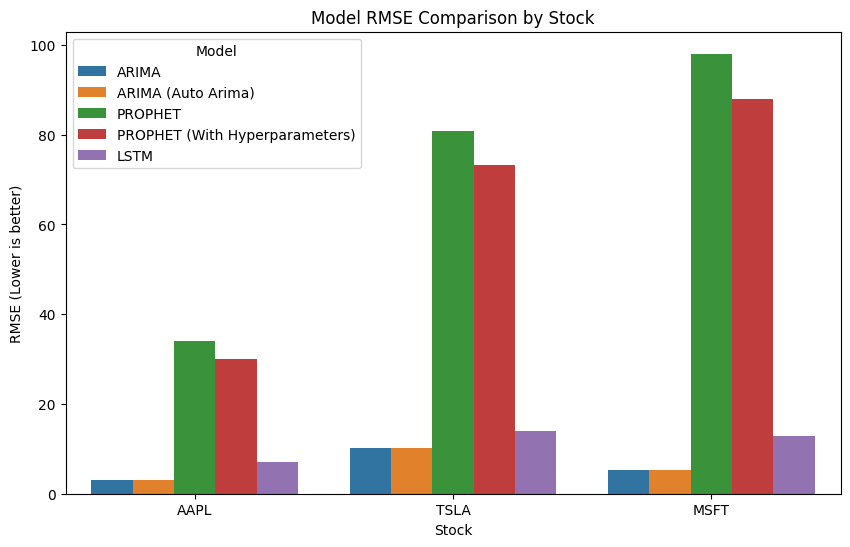

In [35]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Stock', y='RMSE', hue='Model')
plt.title("Model RMSE Comparison by Stock")
plt.ylabel("RMSE (Lower is better)")
plt.show()

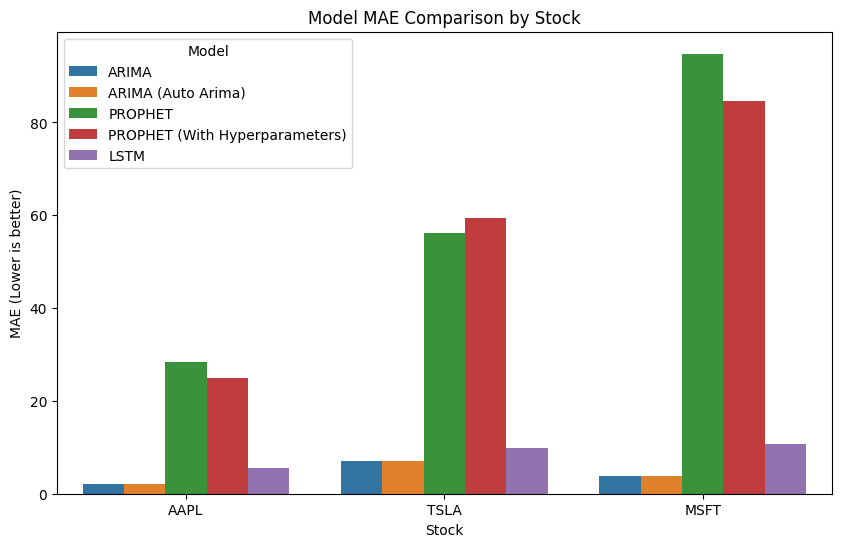

In [36]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Stock', y='MAE', hue='Model')
plt.title("Model MAE Comparison by Stock")
plt.ylabel("MAE (Lower is better)")
plt.show()

In [37]:
def plots(model, stock, model_name):
    fig, axes = plt.subplots(len(stocks), 2, figsize=(18, 5 * len(stocks)))
    for i, stock in enumerate(stocks):
        y_test = model[stock]['y_test']
        y_pred = model[stock]['y_pred']
    
        # Calculate residuals/errors
        residuals = np.array(y_test) - np.array(y_pred)
        errors = np.array(residuals)
        errors = errors[np.isfinite(errors)]
    
        # Residuals vs Predicted
        ax = axes[i, 0]
        ax.scatter(y_pred, residuals, alpha=0.6)
        ax.axhline(0, color='red', linestyle='--')
        ax.set_title(f'{stock} - Residuals vs Predicted for {model_name}')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Residuals')
    
        # Error Distribution
        ax = axes[i, 1]
        sns.histplot(errors, kde=True, ax=ax, bins=30, color='skyblue', edgecolor='black')
        ax.axvline(0, color='red', linestyle='--', label='Zero Error')
        ax.set_title(f'{stock} - Error Distribution for {model_name}')
        ax.set_xlabel('Prediction Error')
        ax.legend()
    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



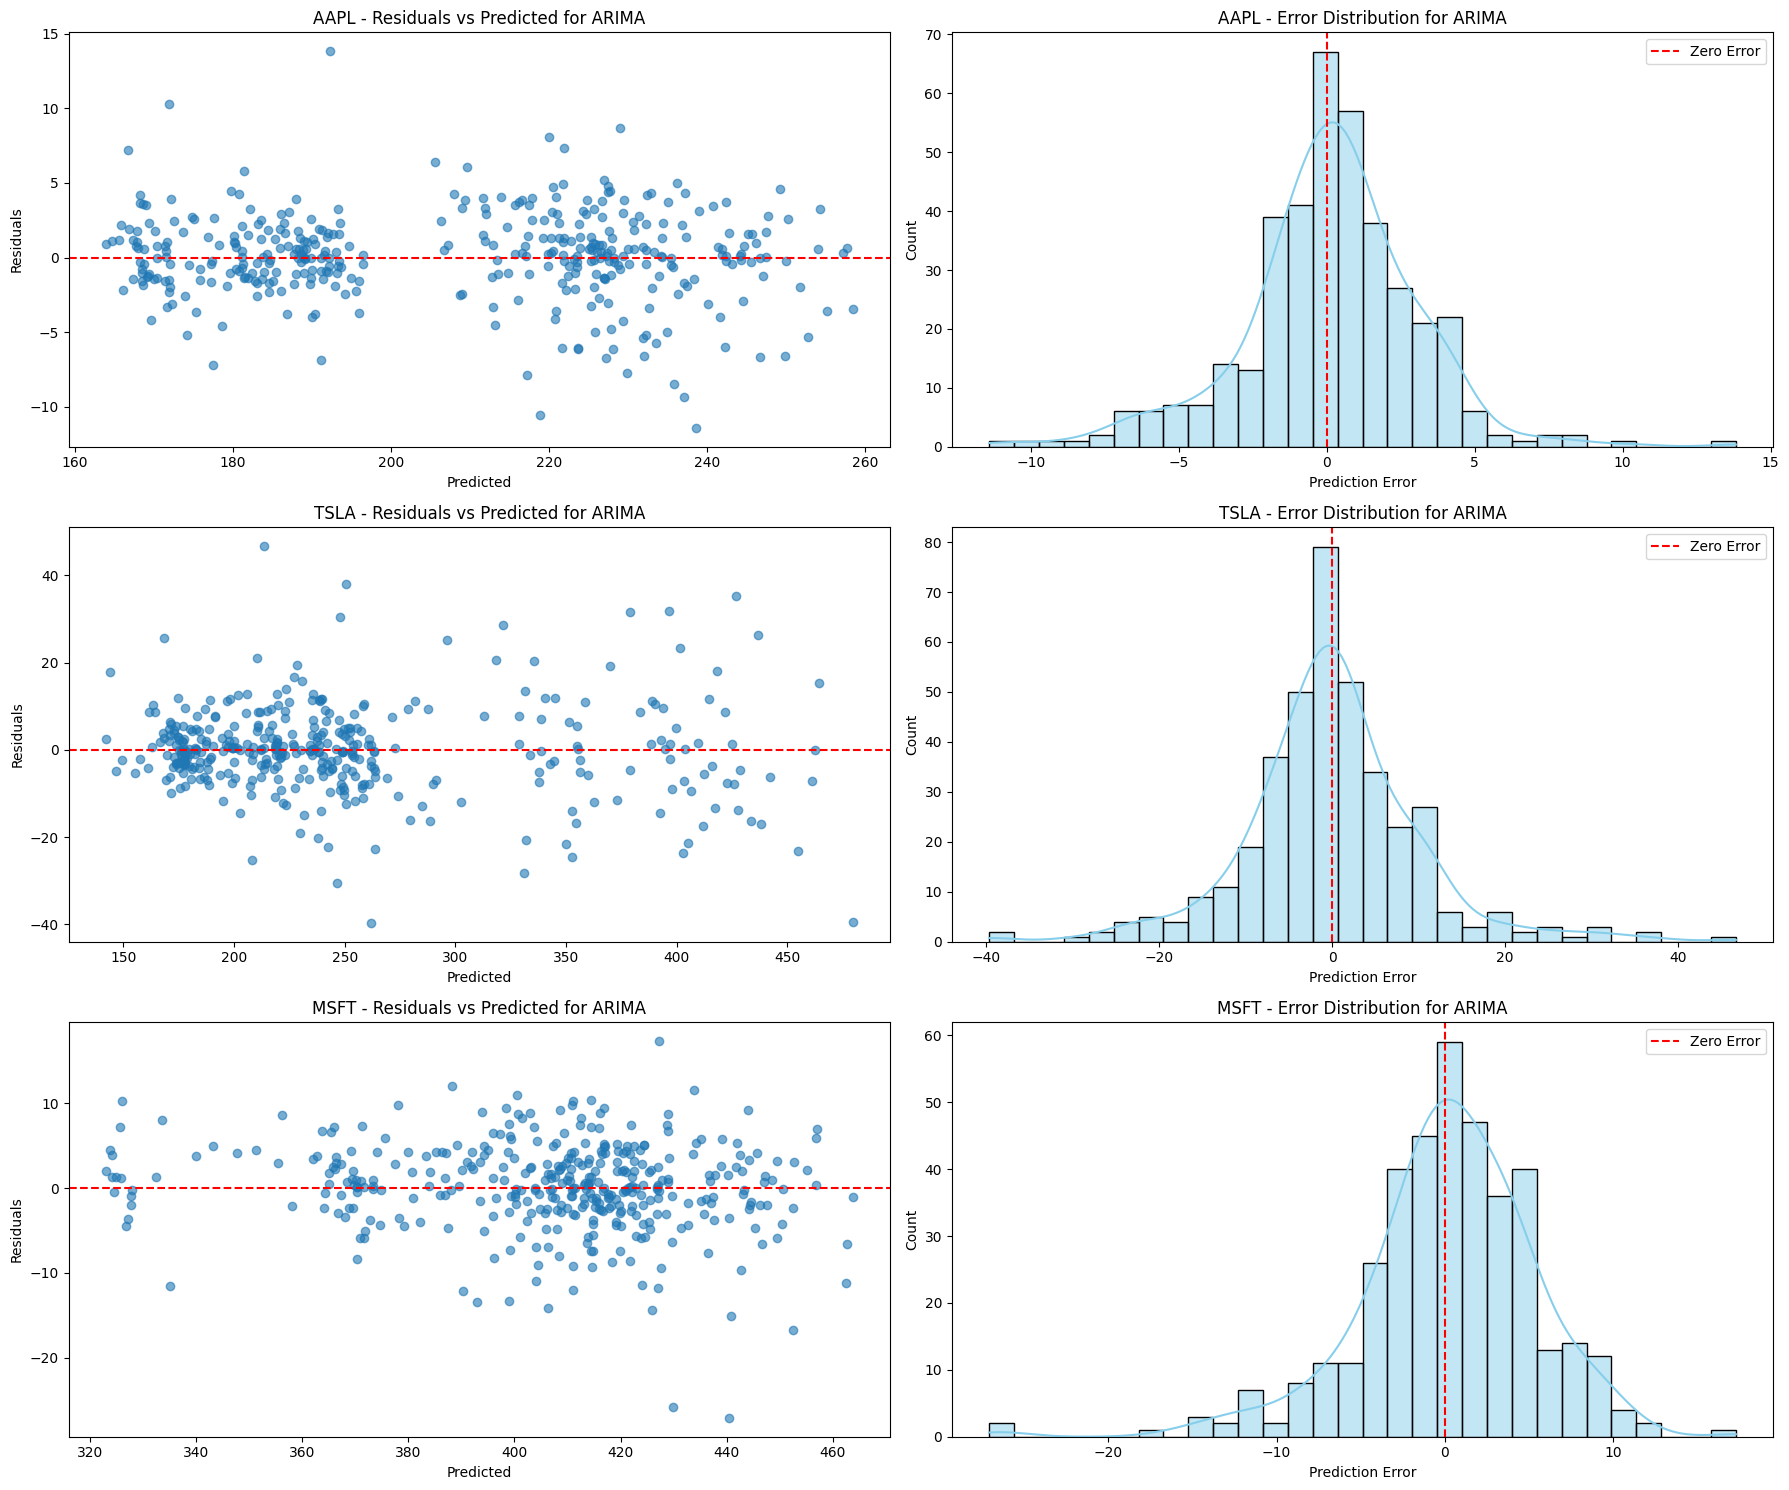

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



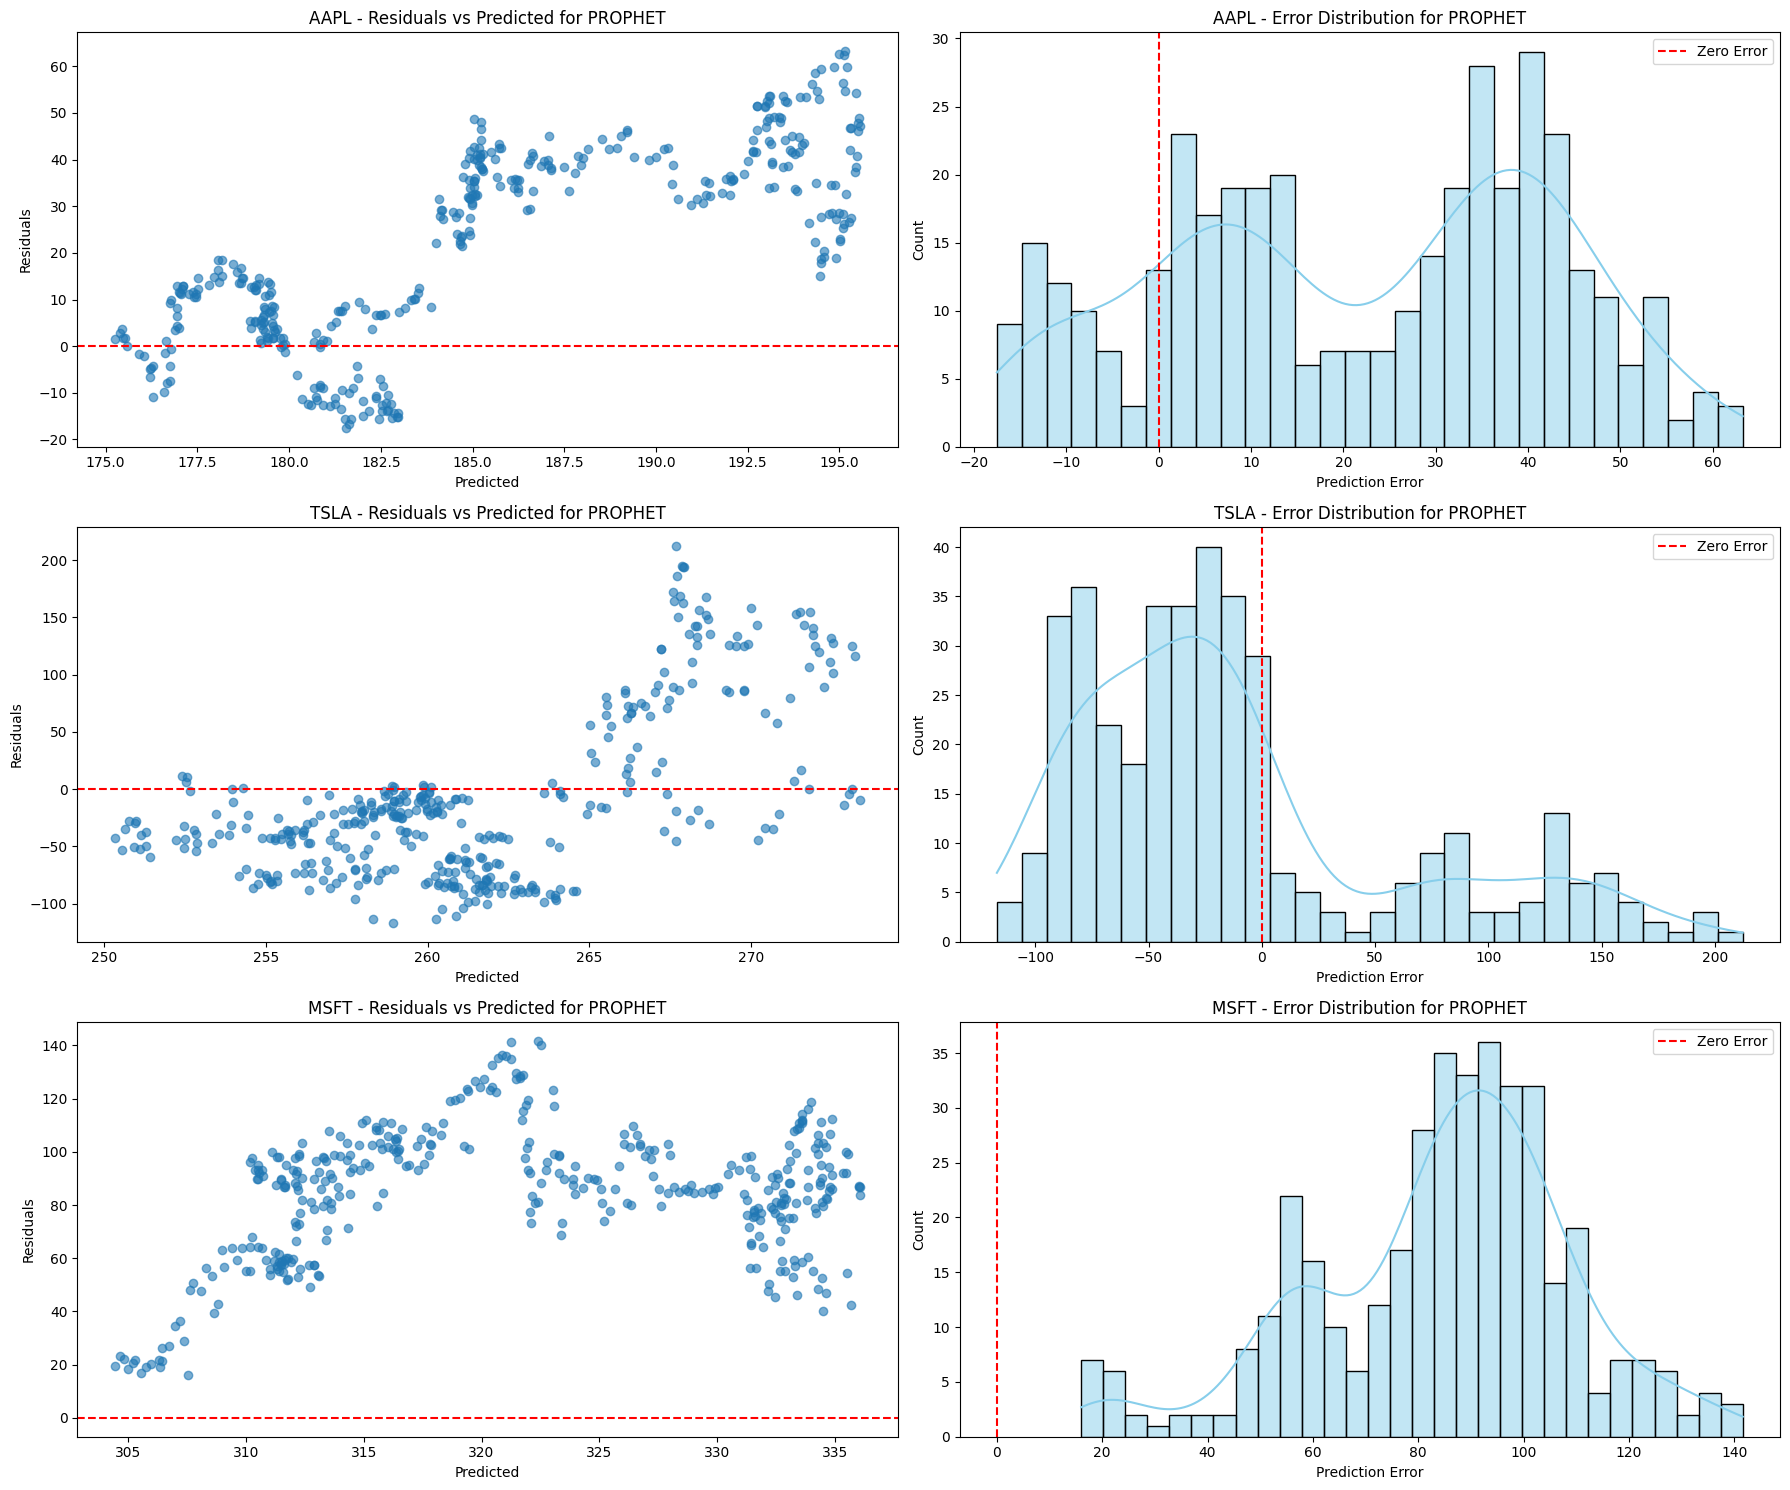

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



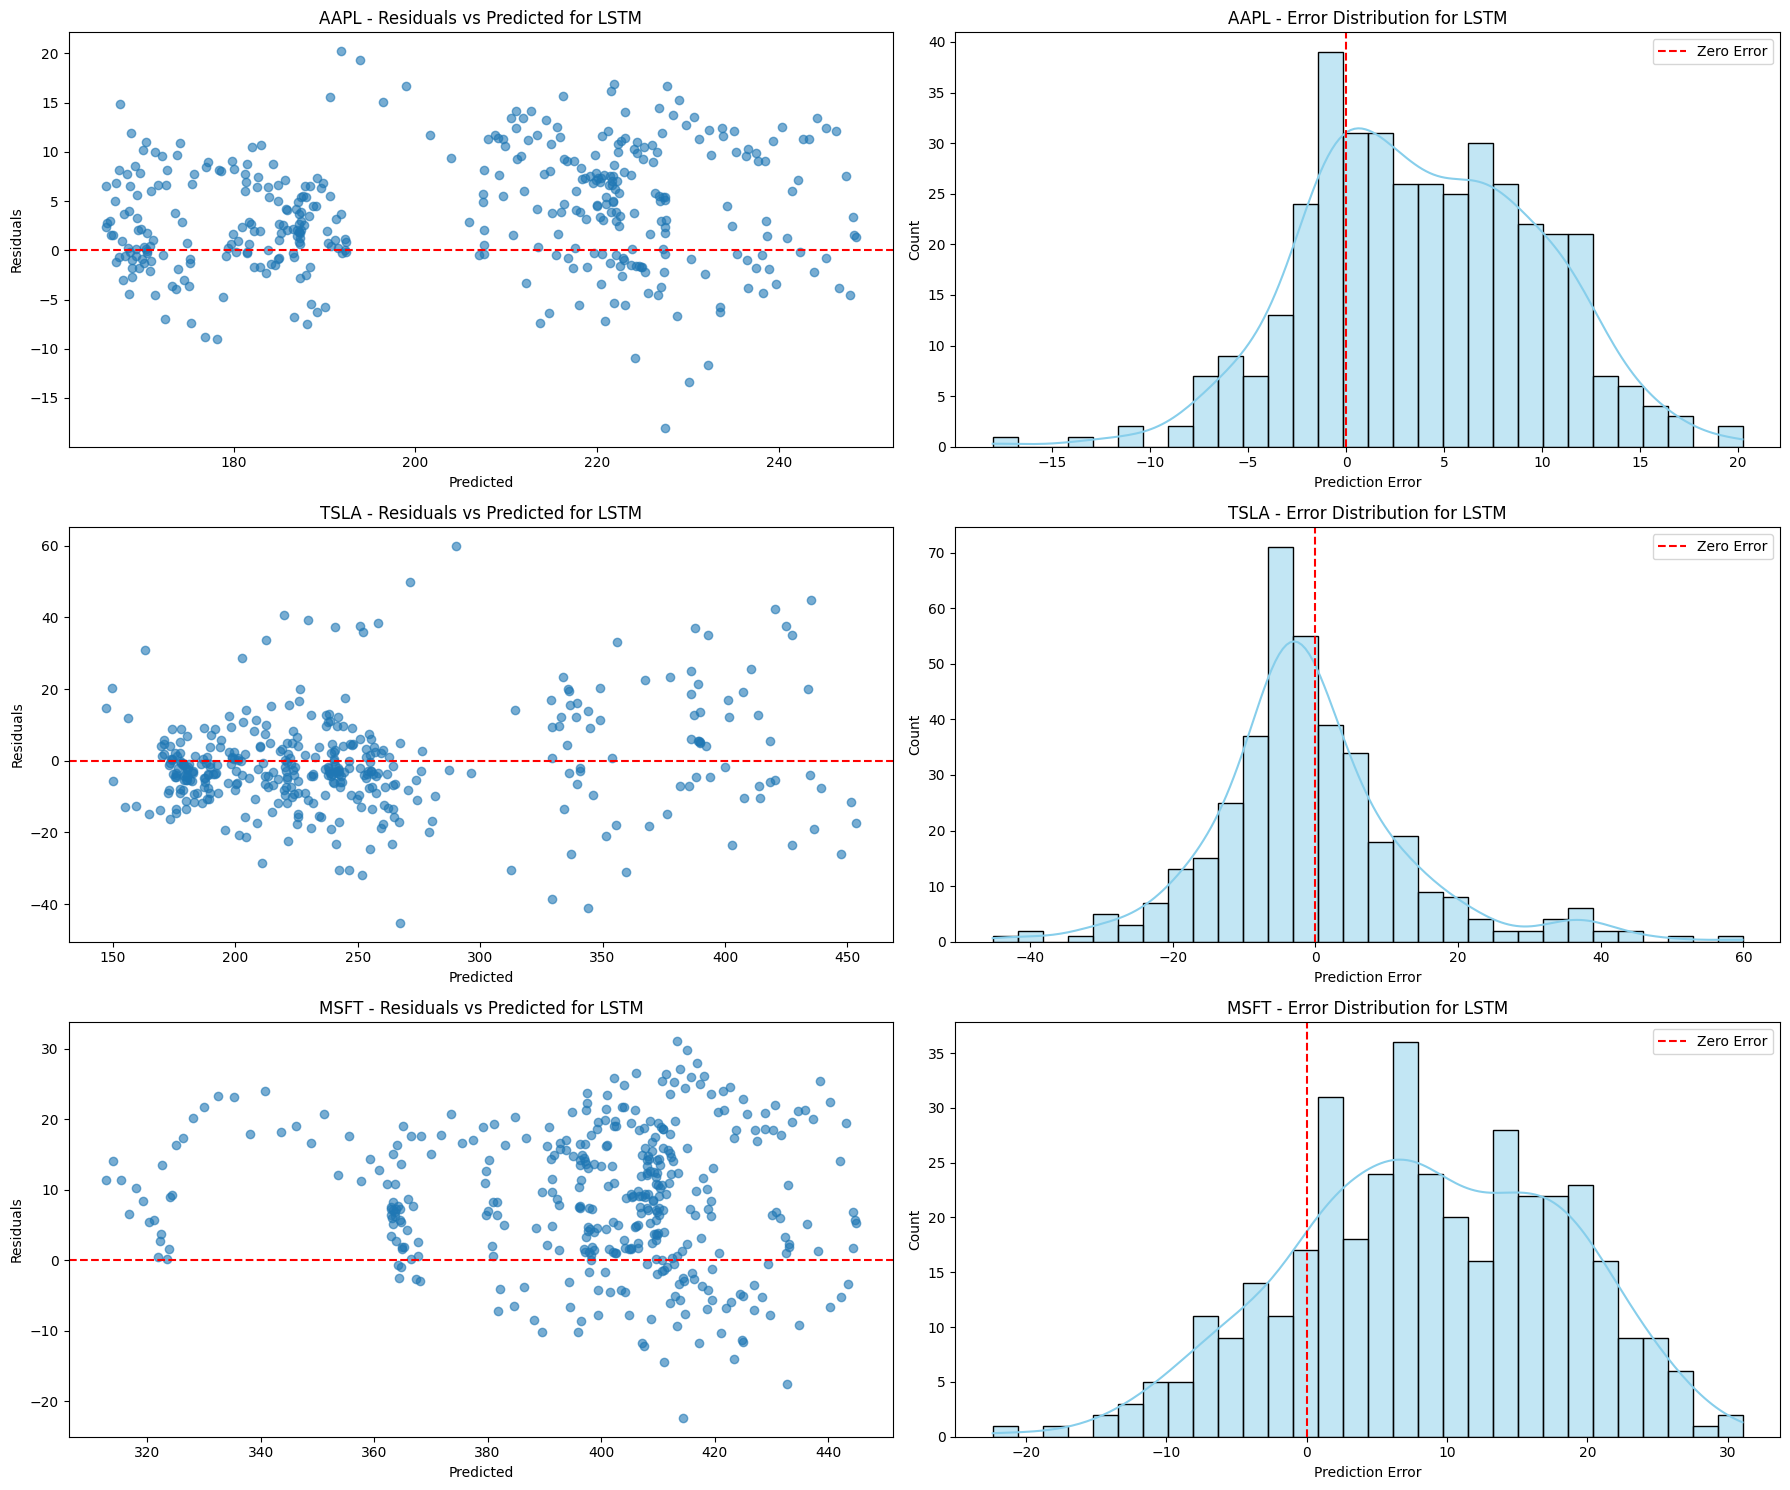

In [38]:
plots(model_arima, stocks, 'ARIMA')
plots(model_prophet_hyperparameters, stocks, 'PROPHET')
plots(model_lstm, stocks, 'LSTM')

# SAVING MODELS

In [39]:
for stock in stocks:
    joblib.dump(model_arima[stock]['model'], f'{stock}_arima.pkl') # model ARIMA
    joblib.dump(model_auto_arima[stock]['model'], f'{stock}_auto_arima.pkl') # model Auto ARIMA
    joblib.dump(model_prophet[stock]['model'], f'{stock}_prophet.pkl') # model Prophet
    joblib.dump(model_prophet_hyperparameters[stock]['model'], f'{stock}_prophet_with_hyperparameters.pkl') # model Prophet with hyperparameters
    model_lstm[stock]['model'].save(f'{stock}_lstm.h5') # model LSTM
    joblib.dump(model_lstm[stock]['scaler'], f'{stock}scaler_for_LSTM.pkl') # MinMaxScaler for LSTM